# Ghost-partition PINN flux reconstruction — MMS boundary-tip fracture

Two-sided flux reconstruction on a domain split by the full-diagonal fracture
$\Gamma=\{(t,t):0\le t\le 1\}$ (tips on $\partial\Omega$).

$$
q_{\theta}(x)=
\begin{cases}
q_\theta^+(x), & x \in \Omega^+=\{y>x\},\\
q_\theta^-(x), & x \in \Omega^-=\{y<x\}.
\end{cases}
$$

The fracture spans the full diagonal so there is **no ghost extension**; `loss_ghost` is identically zero.
The MMS exact solution uses $p_m=\sin(\pi x)\sin(\pi y)+|x-y|\sin(\pi x)\sin(\pi y)/\sqrt{2}$ — see the MMS cell below.


## Manufactured Solution (MMS)

Mesh: `regular_mesh_with_fracture_{ref}.msh`, fracture $\Gamma=\{(t,t):0\le t\le 1\}$, $k_m=1$, $k_f=100$, $\alpha=1$.

| Field | Exact expression |
|---|---|
| $p_m(x,y)$ | $q+\alpha|r|q$, $q=\sin(\pi x)\sin(\pi y)$, $r=(x-y)/\sqrt{2}$ |
| $p_f(t)=p_m(t,t)$ | $\sin^2(\pi t)$ |
| $\lambda(t) = \langle\!\langle \mathbf{K}\nabla p\cdot\mathbf{n}_\gamma\rangle\!\rangle$ | $-2\alpha\sin^2(\pi t)$ **(negative)** |
| $f_m$ on $x>y$ | $2\pi^2q+2\alpha\pi^2rq-\alpha\sqrt{2}\pi\sin(\pi(y-x))$ |
| $f_m$ on $x<y$ | $2\pi^2q-2\alpha\pi^2rq+\alpha\sqrt{2}\pi\sin(\pi(y-x))$ |
| $f_f=-k_f\Delta_s p_f+\lambda$ | $-100\pi^2\cos(2\pi t)-2\alpha\sin^2(\pi t)$ |

**Sign convention (paper + distributional analysis):**  
Strong form $\operatorname{div}(-\mathbf{K}\nabla p)-\lambda=f_m$ gives $\lambda = [[\mathbf{q}_m\cdot\mathbf{n}_\Gamma]]_{\rm std}$.  
Paper notation: $\langle\!\langle\mathbf{K}\nabla p\cdot\mathbf{n}_\gamma\rangle\!\rangle = (\mathbf{K}\nabla p)^-\cdot\mathbf{n}_\Gamma - (\mathbf{K}\nabla p)^+\cdot\mathbf{n}_\Gamma = [[\mathbf{q}_m\cdot\mathbf{n}_\Gamma]]$.  
With $\mathbf{n}_\Gamma=(-1/\sqrt{2},1/\sqrt{2})$ (toward $\Omega^+=\{y>x\}$): $\lambda=-2\alpha\sin^2(\pi t)<0$.  
Physical: $\lambda<0$ acts as a **sink** in the matrix ($-\lambda>0$ in forcing) and **source** in the fracture ($-\lambda>0$ from fracture RHS).

**All consistency checks pass** ($p_m=0$ on $\partial\Omega$, $p_f=0$ at tips, $\lambda(0)=\lambda(1)=0$, fracture PDE residual$=0$).

**Tip-exclusion:** `TIP_FRAC` in the MMS-verify cell controls how much of each fracture tip is excluded from the $L^2$ error (default 0.05 = 5%).

## 0. Convergence analysis

Run the same LCG MMS solve on `regular_mesh_with_fracture_{ref}.msh` for `ref = 2, ..., 9`. This cell only stores the convergence table in `conv_results`; the section below still builds the `ref=5` solution used by the PINN reconstruction cells.


In [34]:
# Convergence analysis for the LCG reference solve.
# This repeats the same MMS formulation used in Section 1 for ref = 2, ..., 9.
from mpi4py import MPI
import gmsh
import numpy as np
from dolfinx import mesh, fem
from dolfinx.fem import petsc
import ufl
import matplotlib.tri as mtri
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm
from matplotlib.transforms import Bbox
import matplotlib as mpl
import pathlib

try:
    from dolfinx.io import gmsh as gmshio
except ImportError:
    from dolfinx.io import gmshio

RUN_CONVERGENCE = False
CONV_REFS = list(range(3, 9)) if RUN_CONVERGENCE else []
CONV_TIP_FRAC = 0.1
FEM_ORDER = 2
# Section 0 mesh/error plots use CG1 nodal triangles; disable them automatically for CG2+.
CONV_PLOT_REQUESTED = True
CONV_PLOT = CONV_PLOT_REQUESTED and FEM_ORDER == 1

Lx, Ly = 1.0, 1.0
y_start, y_end = 0.0, 1.0
x_start, x_end = 0.0, 1.0

ALPHA = 1.0
K_M_VALUE = 1.0
K_F_VALUE = 100.0

def q_exact_xy(x0, y0):
    return np.sin(np.pi * x0) * np.sin(np.pi * y0)

def r_exact_xy(x0, y0):
    return (x0 - y0) / np.sqrt(2.0)

def p_m_exact_fn(x):
    q = q_exact_xy(x[0], x[1])
    return q + ALPHA * np.abs(r_exact_xy(x[0], x[1])) * q

def p_f_exact_fn(t):
    return np.sin(np.pi * t)**2

def lam_exact_fn(t):
    # Paper convention used in Section 1: lambda is negative for this MMS.
    return -2.0 * ALPHA * np.sin(np.pi * t)**2

def f_m_exact_xy(x0, y0):
    q = q_exact_xy(x0, y0)
    r = r_exact_xy(x0, y0)
    sign_r = np.where(r >= 0.0, 1.0, -1.0)
    return (
        2.0 * np.pi**2 * q
        + 2.0 * ALPHA * np.pi**2 * np.abs(r) * q
        - ALPHA * np.sqrt(2.0) * np.pi * sign_r * np.sin(np.pi * (y0 - x0))
    )

def ff_callable(x):
    t = x[0]
    return -K_F_VALUE * np.pi**2 * np.cos(2.0 * np.pi * t) + lam_exact_fn(t)

def k_callable(x):
    return (x[0] * 0 + K_M_VALUE)[np.newaxis, :]

def solve_lcg_mms(ref, tip_frac=CONV_TIP_FRAC, verbose=False):
    filename = f"regular_mesh_with_fracture_{ref}.msh"
    msh, cell_markers, facet_markers = gmshio.read_from_msh(filename, MPI.COMM_WORLD, 0, gdim=2)[0:3]
    comm = msh.comm

    tdim = msh.topology.dim
    fdim = tdim - 1
    omega = msh
    gamma_entities = facet_markers.find(2)
    gamma, gamma_to_omega, gamma_vertex_to_omega = mesh.create_submesh(omega, fdim, gamma_entities)[0:3]

    Gamma_tag = 2
    order = FEM_ORDER
    V_m = fem.functionspace(omega, ("Lagrange", order))
    V_f = fem.functionspace(gamma, ("Lagrange", order))
    V_l = fem.functionspace(gamma, ("Lagrange", order))
    W = ufl.MixedFunctionSpace(V_m, V_f, V_l)

    phi, psi, mu = ufl.TestFunctions(W)
    dp_m, dp_f, dl = ufl.TrialFunctions(W)
    p_m = fem.Function(V_m, name="p_m")
    p_f = fem.Function(V_f, name="p_f")
    lmbd = fem.Function(V_l, name="lmbd")

    x = ufl.SpatialCoordinate(msh)
    q_ufl = ufl.sin(np.pi * x[0]) * ufl.sin(np.pi * x[1])
    r_ufl = (x[0] - x[1]) / np.sqrt(2.0)
    abs_r_ufl = ufl.conditional(ufl.ge(r_ufl, 0.0), r_ufl, -r_ufl)
    sign_r_ufl = ufl.conditional(ufl.ge(r_ufl, 0.0), 1.0, -1.0)
    f_m_ufl = (
        2.0 * np.pi**2 * q_ufl
        + 2.0 * ALPHA * np.pi**2 * abs_r_ufl * q_ufl
        - ALPHA * np.sqrt(2.0) * np.pi * sign_r_ufl * ufl.sin(np.pi * (x[1] - x[0]))
    )

    f_f = fem.Function(V_f)
    f_f.interpolate(ff_callable)

    k_m = fem.Function(V_m)
    k_m.interpolate(k_callable)

    k_f = fem.Function(V_f)
    k_f.x.array[:] = K_F_VALUE

    dx = ufl.Measure("dx", domain=omega)
    ds = ufl.Measure("ds", domain=omega, subdomain_data=facet_markers, subdomain_id=Gamma_tag)
    dx_f = ufl.Measure("dx", domain=gamma)

    coords = omega.geometry.x
    xx = coords[:, 0]
    yy = coords[:, 1]
    xmin, xmax = xx.min(), xx.max()
    ymin, ymax = yy.min(), yy.max()
    tol = 1e-10 * max(xmax - xmin, ymax - ymin)

    a_m0 = ufl.inner(k_m * ufl.grad(p_m), ufl.grad(phi)) * dx
    a_m1 = -lmbd * phi * ds
    L_m = f_m_ufl * phi * dx

    a_f0 = ufl.inner(k_f * ufl.grad(p_f), ufl.grad(psi)) * ds
    a_f1 = lmbd * psi * ds
    L_f = f_f * psi * ds

    a_l0 = p_m * mu * ds
    a_l1 = -p_f * mu * ds
    L_l = fem.Constant(msh, 0.0) * mu * ds

    F = (a_m0 + a_m1 - L_m) + (a_f0 + a_f1 - L_f) + (a_l0 + a_l1 - L_l)
    residual = ufl.extract_blocks(F)
    jac = ufl.derivative(F, p_m, dp_m) + ufl.derivative(F, p_f, dp_f) + ufl.derivative(F, lmbd, dl)
    J = ufl.extract_blocks(jac)

    left_dofs = fem.locate_dofs_geometrical(V_m, lambda x: np.isclose(x[0], xmin, atol=tol))
    right_dofs = fem.locate_dofs_geometrical(V_m, lambda x: np.isclose(x[0], xmax, atol=tol))
    bottom_dofs = fem.locate_dofs_geometrical(V_m, lambda x: np.isclose(x[1], ymin, atol=tol))
    top_dofs = fem.locate_dofs_geometrical(V_m, lambda x: np.isclose(x[1], ymax, atol=tol))
    all_dofs = np.unique(np.concatenate([left_dofs, right_dofs, bottom_dofs, top_dofs]))
    p_m_bc = fem.Function(V_m)
    p_m_bc.x.array[:] = 0.0
    bc_pm = fem.dirichletbc(p_m_bc, all_dofs)

    tol_g = 1e-10 * np.max(np.ptp(gamma.geometry.x, axis=0))
    tip1_dofs = fem.locate_dofs_geometrical(
        V_f,
        lambda x: np.logical_and(np.isclose(x[0], x_start, atol=tol_g),
                                 np.isclose(x[1], y_start, atol=tol_g)),
    )
    tip2_dofs = fem.locate_dofs_geometrical(
        V_f,
        lambda x: np.logical_and(np.isclose(x[0], x_end, atol=tol_g),
                                 np.isclose(x[1], y_end, atol=tol_g)),
    )
    both_tips = np.unique(np.concatenate([tip1_dofs, tip2_dofs]))
    pf_fun = fem.Function(V_f)
    pf_fun.x.array[:] = 0.0
    bc_pf = fem.dirichletbc(pf_fun, both_tips)
    bcs = [bc_pm, bc_pf]

    entity_maps = [gamma_to_omega]
    petsc_options = {
        "snes_max_it": 200,
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
        "mat_mumps_icntl_14": 120,
        "ksp_error_if_not_converged": True,
        "snes_error_if_not_converged": True,
    }
    if verbose:
        petsc_options["snes_monitor"] = None

    nlp = petsc.NonlinearProblem(
        residual,
        u=[p_m, p_f, lmbd],
        J=J,
        bcs=bcs,
        entity_maps=entity_maps,
        petsc_options=petsc_options,
        petsc_options_prefix=f"conv_ref{ref}_",
    )
    nlp.solve()
    iterations = nlp.solver.getIterationNumber()

    # Interpolated exact fields are kept for plotting and later diagnostics only.
    # The reported convergence errors below are integrated against analytic MMS
    # expressions at quadrature points, not against FE interpolants.
    p_m_ex = fem.Function(V_m)
    p_m_ex.interpolate(p_m_exact_fn)
    p_f_ex = fem.Function(V_f)
    p_f_ex.interpolate(lambda x: p_f_exact_fn(x[0]))
    lam_ex = fem.Function(V_l)
    lam_ex.interpolate(lambda x: lam_exact_fn(x[0]))

    err_quad_degree = max(8, 2 * order + 6)
    dx_err = ufl.Measure("dx", domain=omega, metadata={"quadrature_degree": err_quad_degree})
    dx_f_err = ufl.Measure("dx", domain=gamma, metadata={"quadrature_degree": err_quad_degree})
    x_gamma = ufl.SpatialCoordinate(gamma)
    p_m_exact_ufl = q_ufl + ALPHA * abs_r_ufl * q_ufl
    p_f_exact_ufl = ufl.sin(np.pi * x_gamma[0]) ** 2
    lam_exact_ufl = -2.0 * ALPHA * ufl.sin(np.pi * x_gamma[0]) ** 2

    def sqrt_global(form_expr):
        local = fem.assemble_scalar(fem.form(form_expr))
        return np.sqrt(comm.allreduce(local, op=MPI.SUM))

    err_pm = sqrt_global((p_m - p_m_exact_ufl) ** 2 * dx_err)
    err_pf = sqrt_global((p_f - p_f_exact_ufl) ** 2 * dx_f_err)
    err_lam = sqrt_global((lmbd - lam_exact_ufl) ** 2 * dx_f_err)

    t_gamma = x_gamma[0]
    interior = ufl.conditional(
        ufl.ge(t_gamma, tip_frac),
        ufl.conditional(ufl.le(t_gamma, 1.0 - tip_frac), 1.0, 0.0),
        0.0,
    )
    err_lam_int = sqrt_global(interior * (lmbd - lam_exact_ufl) ** 2 * dx_f_err)

    ndof_pm = p_m.function_space.dofmap.index_map.size_global
    ndof_pf = p_f.function_space.dofmap.index_map.size_global
    ndof_lam = lmbd.function_space.dofmap.index_map.size_global

    plot_dof_coords = plot_triangles = plot_pm = plot_pm_ex = None
    if CONV_PLOT:
        # Plotting arrays: DOF coordinates and values for V_m (CG1 = nodes).
        n_cells_local = omega.topology.index_map(tdim).size_local
        plot_dof_coords = V_m.tabulate_dof_coordinates()[:, :2].copy()
        plot_triangles = np.array([V_m.dofmap.cell_dofs(i) for i in range(n_cells_local)])
        plot_pm    = p_m.x.array.copy()
        plot_pm_ex = p_m_ex.x.array.copy()

    return {
        "ref": ref,
        "h": 1.0 / (2**ref),
        "ndof_pm": ndof_pm,
        "ndof_pf": ndof_pf,
        "ndof_lam": ndof_lam,
        "ndof_total": ndof_pm + ndof_pf + ndof_lam,
        "iterations": iterations,
        "err_pm": err_pm,
        "err_pf": err_pf,
        "err_lam": err_lam,
        "err_lam_int": err_lam_int,
        "plot_dof_coords": plot_dof_coords,
        "plot_triangles": plot_triangles,
        "plot_pm": plot_pm,
        "plot_pm_ex": plot_pm_ex,
    }

def add_rates(rows):
    for i, row in enumerate(rows):
        for key in ("err_pm", "err_pf", "err_lam_int"):
            row[f"rate_{key}"] = np.nan
            if i > 0 and row[key] > 0 and rows[i - 1][key] > 0:
                row[f"rate_{key}"] = np.log(rows[i - 1][key] / row[key]) / np.log(rows[i - 1]["h"] / row["h"])
    return rows

def fmt_rate(value):
    return "  -  " if not np.isfinite(value) else f"{value:5.2f}"

conv_results = []
err_vmax = None  # set from coarsest mesh, reused for all error colorbars
for ref in CONV_REFS:
    if MPI.COMM_WORLD.rank == 0:
        print(f"\n--- LCG MMS convergence ref={ref} ---")
    conv_results.append(solve_lcg_mms(ref, tip_frac=CONV_TIP_FRAC, verbose=False))
    add_rates(conv_results)
    row = conv_results[-1]
    if MPI.COMM_WORLD.rank == 0:
        print(
            f"h={row['h']:.3e}, total dofs={row['ndof_total']}, Newton it={row['iterations']}, "
            f"err_pm={row['err_pm']:.3e}, err_pf={row['err_pf']:.3e}, "
            f"err_lambda_h_tip={row['err_lam_int']:.3e}"
        )

    if CONV_PLOT and MPI.COMM_WORLD.rank == 0:
        coords  = row["plot_dof_coords"]
        tris    = row["plot_triangles"]
        pm_vals = row["plot_pm"]
        pm_ex_v = row["plot_pm_ex"]
        diff    = np.abs(pm_vals - pm_ex_v)
        if err_vmax is None:  # coarsest mesh sets the shared error scale
            err_vmax = float(diff.max())

        tri_obj = mtri.Triangulation(coords[:, 0], coords[:, 1], tris)
        vmin_p  = float(min(pm_vals.min(), pm_ex_v.min()))
        vmax_p  = float(max(pm_vals.max(), pm_ex_v.max()))
        # Log-scale norm for error (floor = 4 decades below coarsest-mesh max)
        err_floor  = err_vmax * 1e-8
        err_levels = np.logspace(np.log10(err_floor), np.log10(err_vmax), 15)
        norm_err   = LogNorm(vmin=err_floor, vmax=err_vmax)

        def _attach_cbar(fig, ax, mappable, label=""):
            """Colorbar that exactly matches the axes height (= domain square)."""
            div = make_axes_locatable(ax)
            cax = div.append_axes("right", size="5%", pad=0.06)
            fig.colorbar(mappable, cax=cax, label=label)

        fig, axes = plt.subplots(1, 4, figsize=(22, 5), constrained_layout=True)
        fig.suptitle(
            fr"LCG MMS — ref={row['ref']}, $h$={row['h']:.3e}, "
            fr"$\|p_h-p_{{\rm exact}}\|_{{L^2}}$={row['err_pm']:.2e}",
            fontsize=12,
        )

        # Panel 0: mesh + fracture
        axes[0].triplot(tri_obj, lw=0.3, color="0.55")
        axes[0].plot([x_start, x_end], [y_start, y_end],
                     "r-", lw=2, label=r"$\Gamma$")
        axes[0].set_aspect("equal"); axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)
        axes[0].set_title("Mesh")
        axes[0].legend(fontsize=8, loc="upper left")
        div0 = make_axes_locatable(axes[0])  # invisible cbar to align spacing
        cax0 = div0.append_axes("right", size="5%", pad=0.06)
        cax0.axis("off")

        # Panel 1: CG pressure
        im1 = axes[1].tripcolor(tri_obj, pm_vals, shading="gouraud",
                                vmin=vmin_p, vmax=vmax_p, cmap="jet")
        axes[1].plot([x_start, x_end], [y_start, y_end], "k--", lw=1.5)
        axes[1].set_aspect("equal"); axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)
        axes[1].set_title(r"$p_h$")
        _attach_cbar(fig, axes[1], im1)

        # Panel 2: exact pressure
        im2 = axes[2].tripcolor(tri_obj, pm_ex_v, shading="gouraud",
                                vmin=vmin_p, vmax=vmax_p, cmap="jet")
        axes[2].plot([x_start, x_end], [y_start, y_end], "k--", lw=1.5)
        axes[2].set_aspect("equal"); axes[2].set_xlim(0, 1); axes[2].set_ylim(0, 1)
        axes[2].set_title(r"$p_{\rm exact}$")
        _attach_cbar(fig, axes[2], im2)

        # Panel 3: pointwise error at CG DOFs
        # extend="min" fills sub-floor values with the lowest colour (avoids white corners)
        im3 = axes[3].tricontourf(tri_obj, diff, levels=err_levels, norm=norm_err,
                                  cmap="jet", extend="min")
        axes[3].plot([x_start, x_end], [y_start, y_end], "k--", lw=1.5)
        axes[3].set_aspect("equal"); axes[3].set_xlim(0, 1); axes[3].set_ylim(0, 1)
        axes[3].set_title(r"$|p_h - p_{\rm exact}|$")
        # Use ScalarMappable so the colorbar ticks follow LogNorm, not contour levels
        sm3 = mpl.cm.ScalarMappable(cmap="jet", norm=norm_err)
        sm3.set_array([])
        _attach_cbar(fig, axes[3], sm3)

        out_dir = pathlib.Path("fracture_problem")
        out_dir.mkdir(parents=True, exist_ok=True)

        # Draw so bboxes are populated before cropped saves.
        # fig.axes order: [ax0, ax1, ax2, ax3, cax0(inv), cax1, cax2, cax3]
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()

        def _crop(axs):
            bbs = [ax.get_tightbbox(renderer) for ax in axs]
            return Bbox.union([b for b in bbs if b is not None]).transformed(
                fig.dpi_scale_trans.inverted())

        ref_tag = row["ref"]
        fig.savefig(out_dir / f"lcg_mms_ref{ref_tag}_mesh.png",
                    bbox_inches=_crop([axes[0]]), dpi=200)
        fig.savefig(out_dir / f"lcg_mms_ref{ref_tag}_ph.png",
                    bbox_inches=_crop([axes[1], fig.axes[5]]), dpi=200)
        fig.savefig(out_dir / f"lcg_mms_ref{ref_tag}_error.png",
                    bbox_inches=_crop([axes[3], fig.axes[7]]), dpi=200)
        plt.show()
        plt.close(fig)

if RUN_CONVERGENCE and MPI.COMM_WORLD.rank == 0:
    print("\nConvergence table")
    print(
        f"{'ref':>3} {'h':>10} {'dofs':>9} {'it':>3} "
        f"{'||pm||':>11} {'r':>5} {'||pf||':>11} {'r':>5} "
        f"{'||lambda_h||tip':>16} {'r':>5} {'||lambda_h||full':>18}"
    )
    for row in conv_results:
        print(
            f"{row['ref']:3d} {row['h']:10.3e} {row['ndof_total']:9d} {row['iterations']:3d} "
            f"{row['err_pm']:11.3e} {fmt_rate(row['rate_err_pm']):>5} "
            f"{row['err_pf']:11.3e} {fmt_rate(row['rate_err_pf']):>5} "
            f"{row['err_lam_int']:12.3e} {fmt_rate(row['rate_err_lam_int']):>5} "
            f"{row['err_lam']:12.3e}"
        )


In [35]:
try:
    import matplotlib.pyplot as plt

    # Select refinements to include in the convergence plot.
    # Use None, "all", or [] for every computed refinement; e.g. [5, 6, 7, 8].
    # CONV_PLOT_REFS = None
    CONV_PLOT_REFS = [4,5,6,7,8]

    # Dashed benchmark-line orders for each plotted quantity.
    CONV_BENCHMARK_ORDERS = {
        "p": float(FEM_ORDER + 1),
        "p_Gamma": float(FEM_ORDER + 1),
        "lambda": float(FEM_ORDER + 1),
    }

    # Select the refinement where the benchmark lines are anchored.
    # Use None for the coarsest plotted refinement, one int for all lines,
    # or a dict such as {"p": 5, "p_Gamma": 5, "lambda": 6}.
    CONV_BENCHMARK_ANCHOR_REF = {"p": 5, "p_Gamma": 5, "lambda": 6}

    def selected_convergence_rows(rows, selected_refs):
        if selected_refs is None:
            return list(rows)
        if isinstance(selected_refs, str):
            if selected_refs.lower() == "all":
                return list(rows)
            requested = [int(ref.strip()) for ref in selected_refs.split(",") if ref.strip()]
        elif isinstance(selected_refs, (int, np.integer)):
            requested = [int(selected_refs)]
        else:
            requested = [int(ref) for ref in selected_refs]
        if not requested:
            return list(rows)

        available = {int(row["ref"]) for row in rows}
        missing = [ref for ref in requested if ref not in available]
        if missing:
            print(f"Convergence plot warning: refs not available in conv_results: {missing}")
        requested_set = set(requested)
        return [row for row in rows if int(row["ref"]) in requested_set]

    def benchmark_label(order):
        order = float(order)
        if np.isclose(order, 1.0):
            return r"$O(h)$"
        if np.isclose(order, round(order)):
            return rf"$O(h^{int(round(order))})$"
        return rf"$O(h^{{{order:g}}})$"

    def benchmark_anchor_ref(anchor_refs, series_name):
        if isinstance(anchor_refs, dict):
            return anchor_refs.get(series_name, anchor_refs.get("default", None))
        return anchor_refs

    def add_benchmark_line(ax, refs, hs, values, order, h_span=None, anchor_ref=None, legend_label=None):
        mask = np.isfinite(hs) & np.isfinite(values) & (hs > 0.0) & (values > 0.0)
        if np.count_nonzero(mask) < 1:
            return False
        refs_valid = refs[mask]
        h_valid = hs[mask]
        v_valid = values[mask]
        anchor = np.argmax(h_valid)
        if anchor_ref is not None:
            anchor_matches = np.flatnonzero(refs_valid == int(anchor_ref))
            if anchor_matches.size:
                anchor = int(anchor_matches[0])
            else:
                print(f"Benchmark anchor ref={anchor_ref} is not plotted; using coarsest plotted ref.")
        h0 = h_valid[anchor]
        v0 = v_valid[anchor]
        if np.count_nonzero(mask) >= 2:
            h_ref = np.array([h_valid.max(), h_valid.min()])
        elif h_span is not None:
            h_span = np.asarray(h_span, dtype=float)
            h_span = h_span[np.isfinite(h_span) & (h_span > 0.0)]
            h_ref = np.array([h_span.max(), h_span.min()]) if h_span.size >= 2 else h0 * np.array([2.0, 0.5])
        else:
            h_ref = h0 * np.array([2.0, 0.5])
        v_ref = v0 * (h_ref / h0)**float(order)
        ax.loglog(
            h_ref, v_ref, "--", color="black", lw=1.1, alpha=0.75,
            label=legend_label if legend_label is not None else "_nolegend_",
        )
        return True

    plot_rows = selected_convergence_rows(conv_results, CONV_PLOT_REFS)
    if not plot_rows:
        raise ValueError("No convergence rows selected. Check CONV_PLOT_REFS.")

    refs = np.array([row["ref"] for row in plot_rows], dtype=int)
    hs = np.array([row["h"] for row in plot_rows], dtype=float)
    all_hs = np.array([row["h"] for row in conv_results], dtype=float)
    plot_series = [
        ("p", "err_pm", r"$p_h$", "o-"),
        ("p_Gamma", "err_pf", r"$p_{\Gamma,h}$", "s-"),
        ("lambda", "err_lam_int", r"$\lambda_h$", "^-"),
    ]

    fs = 18
    fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
    plotted = []
    for name, err_key, label, style in plot_series:
        values = np.array([row[err_key] for row in plot_rows], dtype=float)
        line, = ax.loglog(hs, values, style, label=label)
        plotted.append((name, label, values, line.get_color()))

    benchmark_legend_added = False
    for name, label, values, color in plotted:
        order = CONV_BENCHMARK_ORDERS.get(name, 2.0)
        anchor_ref = benchmark_anchor_ref(CONV_BENCHMARK_ANCHOR_REF, name)
        legend_label = None if benchmark_legend_added else benchmark_label(order)
        if add_benchmark_line(ax, refs, hs, values, order, h_span=all_hs, anchor_ref=anchor_ref, legend_label=legend_label):
            benchmark_legend_added = True

    selected_refs = [int(row["ref"]) for row in plot_rows]
    print(f"Convergence plot refs: {selected_refs}")
    ax.invert_xaxis()
    ax.set_xticks(hs)
    ax.set_xticklabels([rf"$2^{{-{ref}}}$" for ref in refs])
    ax.set_xlabel("h", fontsize=fs)
    ax.set_ylabel(r"$L^2$ error", fontsize=fs)
    ax.tick_params(axis="both", which="both", labelsize=fs)
    # ax.set_title("LCG MMS convergence")
    ax.grid(False)
    ax.legend(frameon=False, fontsize=fs)
    plt.show()
except Exception as exc:
    print(f"Convergence plot skipped: {exc}")

Convergence plot warning: refs not available in conv_results: [4, 5, 6, 7, 8]
Convergence plot skipped: No convergence rows selected. Check CONV_PLOT_REFS.


## 1. LCG reference solve

Run this notebook in the same directory as the `.msh` files, or update `filename` below.


In [36]:
from mpi4py import MPI
import gmsh
import numpy as np
from scipy.spatial import cKDTree
import pyvista as pv
from dolfinx import plot

N_ref = 8

Lx, Ly = 1.0, 1.0
y_start, y_end = 0.0, 1.0
x_start, x_end = 0.0, 1.0

ALPHA = 1.0
K_M_VALUE = 1.0
K_F_VALUE = 100.0

#REFERENCE SOLUTION
from dolfinx import mesh, fem
import ufl
import numpy as np

# ---------------------------------------------------------------------
# 1. Mesh and interface tags (similar to Γ tagging in the workshop)
# ---------------------------------------------------------------------
# Load Gmsh mesh (2D bulk Ω + 1D interface Γ)
try:
    from dolfinx.io import gmsh as gmshio
except ImportError:
    from dolfinx.io import gmshio
ref = 6
filename = f"regular_mesh_with_fracture_{ref}.msh"
msh, cell_markers, facet_markers = gmshio.read_from_msh(filename, MPI.COMM_WORLD, 0, gdim=2)[0:3]

tdim = msh.topology.dim  # 2
fdim = tdim - 1             # 1

lc = 1.0/ (2**ref)          # mesh size
h = lc

# Find all facets tagged as Gamma (tag=2)
omega = msh
gamma_entities = facet_markers.find(2)

# Create a submesh for Γ (same as gamma in the JSDokken example)
gamma, gamma_to_omega, gamma_vertex_to_omega = mesh.create_submesh(omega, fdim, gamma_entities)[0:3]

# Define interface tag ID (as defined in Gmsh)
Gamma_tag = 2  # <-- replace with your actual tag ID for the interface Γ

# ---------------------------------------------------------------------
# 2. Function spaces
# ---------------------------------------------------------------------
order = 2
V_m = fem.functionspace(omega, ("Lagrange", order))  # bulk Ω
V_f = fem.functionspace(gamma, ("Lagrange", order))   # interface Γ
V_l = fem.functionspace(gamma, ("Lagrange", order))   # multiplier space on Γ
W = ufl.MixedFunctionSpace(V_m, V_f, V_l)

# ---------------------------------------------------------------------
# 3. Trial and Test functions
# ---------------------------------------------------------------------
phi, psi, mu = ufl.TestFunctions(W)
dp_m, dp_f, dl = ufl.TrialFunctions(W)
p_m = fem.Function(V_m, name="p_m")
p_f = fem.Function(V_f, name="p_f")
lmbd = fem.Function(V_l, name="lmbd")

# ---------------------------------------------------------------------
# 4. Spatial coordinates and given data
# ---------------------------------------------------------------------
x = ufl.SpatialCoordinate(msh)

def q_exact_xy(x0, y0):
    return np.sin(np.pi * x0) * np.sin(np.pi * y0)

def r_exact_xy(x0, y0):
    return (x0 - y0) / np.sqrt(2.0)

def p_m_exact_xy(x0, y0):
    q = q_exact_xy(x0, y0)
    return q + ALPHA * np.abs(r_exact_xy(x0, y0)) * q

def p_m_exact_fn(x):
    return p_m_exact_xy(x[0], x[1])

def p_f_exact_fn(t):
    return np.sin(np.pi * t)**2

def lam_exact_fn(t):
    # λ = ⟦K∇p·n_γ⟧ = [[q_m·n_Γ]] = -2α sin²(πt)  (paper convention, negative)
    # Derived: div(-K∇p) - λ = f  →  λ = [[q_m·n_Γ]] = -(K∇p⁺-K∇p⁻)·n_Γ
    return -2.0 * ALPHA * np.sin(np.pi * t)**2

def f_m_exact_xy(x0, y0):
    q = q_exact_xy(x0, y0)
    r = r_exact_xy(x0, y0)
    sign_r = np.where(r >= 0.0, 1.0, -1.0)
    return (
        2.0 * np.pi**2 * q
        + 2.0 * ALPHA * np.pi**2 * np.abs(r) * q
        - ALPHA * np.sqrt(2.0) * np.pi * sign_r * np.sin(np.pi * (y0 - x0))
    )

def f_m_exact_points(points):
    points = np.asarray(points, dtype=float)
    return f_m_exact_xy(points[:, 0], points[:, 1])

def f_callable(x):
    return f_m_exact_xy(x[0], x[1])
f_m = fem.Function(V_m)
f_m.interpolate(f_callable)

q_ufl = ufl.sin(np.pi * x[0]) * ufl.sin(np.pi * x[1])
r_ufl = (x[0] - x[1]) / np.sqrt(2.0)
abs_r_ufl = ufl.conditional(ufl.ge(r_ufl, 0.0), r_ufl, -r_ufl)
sign_r_ufl = ufl.conditional(ufl.ge(r_ufl, 0.0), 1.0, -1.0)
f_m_ufl = (
    2.0 * np.pi**2 * q_ufl
    + 2.0 * ALPHA * np.pi**2 * abs_r_ufl * q_ufl
    - ALPHA * np.sqrt(2.0) * np.pi * sign_r_ufl * ufl.sin(np.pi * (x[1] - x[0]))
)

f_f = fem.Function(V_f)

def ff_callable(x):
    t = x[0]   # on Gamma: x=y=t
    return -K_F_VALUE * np.pi**2 * np.cos(2.0 * np.pi * t) + lam_exact_fn(t)

f_f.interpolate(ff_callable)

# k_m = fem.Constant(omega, 1.0)
k_m = fem.Function(V_m)
# k_m.x.array[:] = 1.0
def k_callable(x):
    return (x[0] * 0 + K_M_VALUE)[np.newaxis, :]   # k_m = 1 (manufactured)

k_m.interpolate(k_callable)

# k_f = fem.Constant(gamma, 10.0)
k_f = fem.Function(V_f)
k_f.x.array[:] = K_F_VALUE

dx = ufl.Measure("dx", domain=omega)
dS_omega = ufl.Measure("dS", domain=omega)   # interior facets of omega
# ds = dS_omega(Gamma_tag)
# ds = ufl.Measure("ds", domain=omega, subdomain_data=facet_markers, subdomain_id=Gamma_tag)
ds = ufl.Measure("ds", domain=omega, subdomain_data=facet_markers, subdomain_id=Gamma_tag) #Gamma is interior boundary
dx_f = ufl.Measure("dx", domain=gamma)

# Compute bounding box to locate sides
coords = omega.geometry.x
xx = coords[:, 0]
yy = coords[:, 1]

xmin, xmax = xx.min(), xx.max()
ymin, ymax = yy.min(), yy.max()

# Tolerance for side detection
tol = 1e-10 * max(xmax - xmin, ymax - ymin)

# No Neumann BCs: q = sin(πx)sin(πy) vanishes on ∂Ω, so p_m = 0 there.

# ---------------------------------------------------------------------
# 5. Weak formulations
# ---------------------------------------------------------------------

# --- Bulk domain Ω ---------------------------------------------------
a_m0 = ufl.inner(k_m * ufl.grad(p_m), ufl.grad(phi)) * dx
a_m1 = -lmbd * phi * ds 
# a_m1 = -ufl.avg(lmbd) * phi * ds
a_m = a_m0 + a_m1
# Use the analytic piecewise MMS source in the variational form.
L_m = (
    f_m_ufl * phi * dx

    # - g_bottom * phi * dsN(10)   # bottom boundary (tag 1)
    # - g_top * phi * dsN(20)      # top boundary (tag 2)
)
# L_m -= g_N * phi * dsN  (no Neumann BCs)


# --- Interface Γ -----------------------------------------------------
a_f0 = ufl.inner(k_f * ufl.grad(p_f), ufl.grad(psi)) * ds
a_f1 = lmbd * psi * ds
a_f = a_f0 + a_f1
L_f = f_f * psi * ds

# --- Lagrange multiplier (constraint tr(p_m) = p_f) ------------------
a_l0 = p_m * mu * ds
a_l1 = -p_f * mu * ds
a_l = a_l0 + a_l1
L_l = fem.Constant(msh, 0.0) * mu * ds

# ---------------------------------------------------------------------
# 6. Combine interface weak form
# ---------------------------------------------------------------------
a_gamma = a_f + a_l
L_gamma = L_f + L_l

F = a_m - L_m + a_gamma - L_gamma
residual = ufl.extract_blocks(F)

jac = ufl.derivative(F, p_m, dp_m) + ufl.derivative(F, p_f, dp_f) + ufl.derivative(F, lmbd, dl)
J = ufl.extract_blocks(jac)

# Locate dofs on each side
left_dofs   = fem.locate_dofs_geometrical(V_m, lambda x: np.isclose(x[0], xmin, atol=tol))
right_dofs  = fem.locate_dofs_geometrical(V_m, lambda x: np.isclose(x[0], xmax, atol=tol))
bottom_dofs = fem.locate_dofs_geometrical(V_m, lambda x: np.isclose(x[1], ymin, atol=tol))
top_dofs    = fem.locate_dofs_geometrical(V_m, lambda x: np.isclose(x[1], ymax, atol=tol))

# Homogeneous Dirichlet on all 4 sides: p_m = 0 on ∂Ω because q = 0 there.
all_dofs = np.unique(np.concatenate([left_dofs, right_dofs, bottom_dofs, top_dofs]))
p_m_bc = fem.Function(V_m)
p_m_bc.x.array[:] = 0.0

# One BC object over the union of dofs with piecewise values
bc_pm = fem.dirichletbc(p_m_bc, all_dofs)

# tolerance scaled to Γ
tol_g = 1e-10 * np.max(np.ptp(gamma.geometry.x, axis=0))

# locate dofs at each tip
tip1_dofs = fem.locate_dofs_geometrical(
    V_f,
    lambda x: np.logical_and(np.isclose(x[0], x_start, atol=tol_g),
                             np.isclose(x[1], y_start, atol=tol_g))
)
tip2_dofs = fem.locate_dofs_geometrical(
    V_f,
    lambda x: np.logical_and(np.isclose(x[0], x_end, atol=tol_g),
                             np.isclose(x[1], y_end, atol=tol_g))
)
# p_f = sin²(πt): at t=0 → 0, at t=1 → 0 (homogeneous tips)
both_tips = np.unique(np.concatenate([tip1_dofs, tip2_dofs]))
pf_fun = fem.Function(V_f)
pf_fun.x.array[:] = 0.0
bc_pf = fem.dirichletbc(pf_fun, both_tips)
bcs = [bc_pm, bc_pf]

print("DOFs in p_m:", p_m.function_space.dofmap.index_map.size_global)
print("DOFs in p_f:", p_f.function_space.dofmap.index_map.size_global)
print("DOFs in λ:", lmbd.function_space.dofmap.index_map.size_global)
total_dofs = (
    p_m.function_space.dofmap.index_map.size_global
    + p_f.function_space.dofmap.index_map.size_global
    + lmbd.function_space.dofmap.index_map.size_global
)
print("Total DOFs:", total_dofs)

from dolfinx.fem import petsc
entity_maps = [gamma_to_omega]

nlp = petsc.NonlinearProblem(
    residual,
    u=[p_m, p_f, lmbd],
    J=J,
    bcs=bcs,
    entity_maps=entity_maps,
    petsc_options={
        "snes_monitor": None,
        "snes_max_it": 200,  # default is 50, set your own limit
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
        "mat_mumps_icntl_14": 120,
        "ksp_error_if_not_converged": True,
        "snes_error_if_not_converged": True,
    },
    petsc_options_prefix="pmix_",
)
max_iterations = 25
normed_diff = 0
tol = 1e-5

nlp.solve()
iterations = nlp.solver.getIterationNumber()
print(f"Converged in {iterations} Newton iterations")

# FEM solutions stored in p_m, p_f, lmbd (compared to exact in next cell)


Info    : Reading 'regular_mesh_with_fracture_6.msh'...
Info    : 36993 entities
Info    : 4225 nodes
Info    : 36993 elements
Info    : Done reading 'regular_mesh_with_fracture_6.msh'
DOFs in p_m: 16641
DOFs in p_f: 129
DOFs in λ: 129
Total DOFs: 16899
  0 SNES Function norm 9.156435405191e+01
  1 SNES Function norm 4.377128644747e-11
Converged in 1 Newton iterations


In [37]:
# ── MMS verification: compare FEM solution to exact ──────────────────
import numpy as np

pi = np.pi

# ── Change TIP_FRAC to exclude more of the fracture tips ─────────────
TIP_FRAC = 0.1   # fraction of fracture length excluded from each tip end

def p_m_exact_fn(x):
    q = np.sin(pi*x[0]) * np.sin(pi*x[1])
    r = (x[0] - x[1]) / np.sqrt(2.0)
    return q + ALPHA * np.abs(r) * q

def p_f_exact_fn(t):
    return np.sin(pi*t)**2

def lam_exact_fn(t):
    # λ = ⟦K∇p·n_γ⟧ = [[q_m·n_Γ]] = -2α sin²(πt)  (paper convention, negative)
    return -2.0 * ALPHA * np.sin(pi*t)**2

# --- bulk L2 error ---
p_m_ex = fem.Function(V_m)
p_m_ex.interpolate(p_m_exact_fn)
err_pm = fem.assemble_scalar(fem.form((p_m - p_m_ex)**2 * dx))
print(f'||p_m - p_m_ex||_L2 = {np.sqrt(err_pm):.4e}')

# --- fracture pressure L2 error ---
p_f_ex = fem.Function(V_f)
p_f_ex.interpolate(lambda x: p_f_exact_fn(x[0]))
err_pf = fem.assemble_scalar(fem.form((p_f - p_f_ex)**2 * dx_f))
print(f'||p_f - p_f_ex||_L2 = {np.sqrt(err_pf):.4e}')

# --- lambda L2 error: full fracture ---
lam_ex = fem.Function(V_l)
lam_ex.interpolate(lambda x: lam_exact_fn(x[0]))
err_lam = fem.assemble_scalar(fem.form((lmbd - lam_ex)**2 * dx_f))
print(f'||lam  - lam_ex ||_L2 (full)            = {np.sqrt(err_lam):.4e}')

# --- lambda L2 error: excluding TIP_FRAC from each tip ---
t_gamma = ufl.SpatialCoordinate(gamma)[0]   # x-coord on Gamma = parameter t
interior = ufl.conditional(
    ufl.ge(t_gamma, TIP_FRAC),
    ufl.conditional(ufl.le(t_gamma, 1.0 - TIP_FRAC), 1.0, 0.0),
    0.0,
)
err_lam_int = fem.assemble_scalar(fem.form(interior * (lmbd - lam_ex)**2 * dx_f))
print(f'||lam  - lam_ex ||_L2 (excl. {TIP_FRAC*100:.0f}% tips) = {np.sqrt(err_lam_int):.4e}')


||p_m - p_m_ex||_L2 = 5.7636e-08
||p_f - p_f_ex||_L2 = 7.8364e-08
||lam  - lam_ex ||_L2 (full)            = 9.8846e+01
||lam  - lam_ex ||_L2 (excl. 10% tips) = 8.5820e-04


## 2. Mesh, fracture, and CG flux utilities


In [38]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from tqdm import tqdm
from dolfinx import geometry

torch.set_default_dtype(torch.float32)
SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Exact fracture endpoints from the original setup.
FRAC_A = np.array([x_start, y_start], dtype=float)
FRAC_B = np.array([x_end, y_end], dtype=float)

tdim = omega.topology.dim
fdim = tdim - 1
gdim = omega.geometry.dim
omega_geometry = omega.geometry.x[:, :2]

omega.topology.create_connectivity(tdim, 0)
omega.topology.create_connectivity(tdim, fdim)
omega.topology.create_connectivity(fdim, tdim)
omega.topology.create_connectivity(fdim, 0)

c2v = omega.topology.connectivity(tdim, 0)
cell_to_facet = omega.topology.connectivity(tdim, fdim)
facet_to_cell = omega.topology.connectivity(fdim, tdim)
facet_to_vertex = omega.topology.connectivity(fdim, 0)

num_cells = omega.topology.index_map(tdim).size_local
local_cell_vertices = [np.asarray(c2v.links(c), dtype=np.int32) for c in range(num_cells)]

def polygon_signed_area(poly):
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)

def order_polygon_vertices(pts):
    pts = np.asarray(pts, dtype=float)
    ctr = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - ctr[1], pts[:, 0] - ctr[0])
    poly = pts[np.argsort(ang)]
    if polygon_signed_area(poly) < 0:
        poly = poly[::-1]
    return poly

cell_polys = [order_polygon_vertices(omega_geometry[verts]) for verts in local_cell_vertices]
cell_centroids = np.vstack([poly.mean(axis=0) for poly in cell_polys])
cell_areas = np.asarray([abs(polygon_signed_area(poly)) for poly in cell_polys])
h_est = float(np.sqrt(np.mean(cell_areas)))
print("num cells:", num_cells, "h_est:", h_est)

# Build q_cg = -k_m grad(p_m).
Wq = fem.functionspace(omega, ("DG", order, (gdim,)))
q_cg_expr = fem.Expression(-k_m * ufl.grad(p_m), Wq.element.interpolation_points)
q_cg_fun = fem.Function(Wq, name="q_cg")
q_cg_fun.interpolate(q_cg_expr)

def eval_fem_function(fun, points, domain=None):
    if domain is None:
        domain = fun.function_space.mesh
    points = np.asarray(points, dtype=float)
    pts3 = np.zeros((points.shape[0], 3), dtype=float)
    pts3[:, :2] = points[:, :2]
    tree = geometry.bb_tree(domain, domain.topology.dim)
    candidates = geometry.compute_collisions_points(tree, pts3)
    colliding = geometry.compute_colliding_cells(domain, candidates, pts3)
    valid_ids, valid_points, valid_cells = [], [], []
    for i in range(points.shape[0]):
        links = colliding.links(i)
        if len(links) > 0:
            valid_ids.append(i)
            valid_points.append(pts3[i])
            valid_cells.append(links[0])
    if not valid_ids:
        return np.full((points.shape[0], 1), np.nan)
    valid_points = np.asarray(valid_points, dtype=float)
    valid_cells = np.asarray(valid_cells, dtype=np.int32)
    vals = np.asarray(fun.eval(valid_points, valid_cells))
    if vals.ndim == 1:
        vals = vals[:, None]
    out = np.full((points.shape[0], vals.shape[1]), np.nan)
    out[np.asarray(valid_ids, dtype=int), :] = vals
    return out

def q_cg_numpy(points):
    vals = eval_fem_function(q_cg_fun, points, omega)
    return vals[:, :2]

def f_numpy(points):
    return f_m_exact_points(points)


device: cpu
num cells: 8192 h_est: 0.011048543456039806


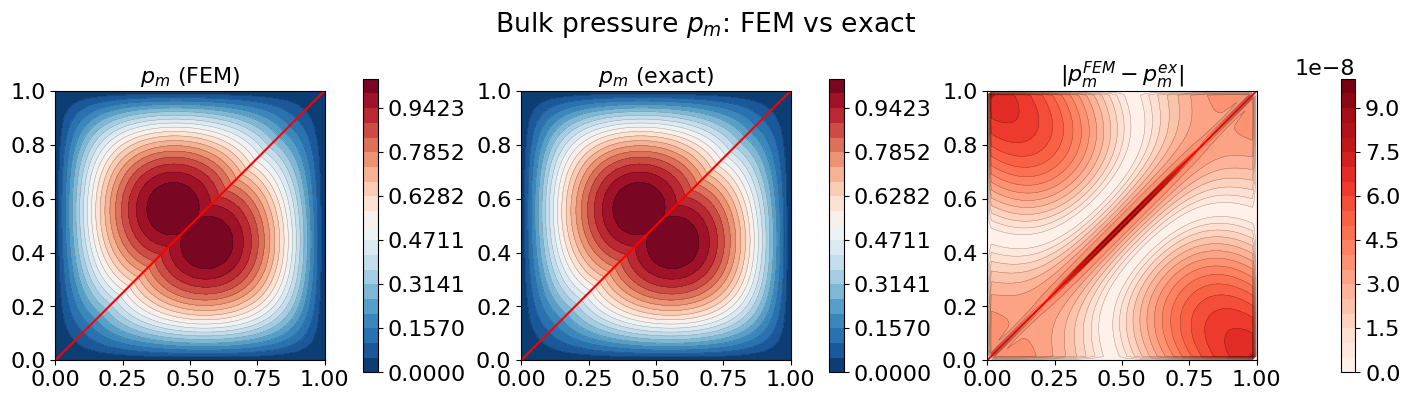

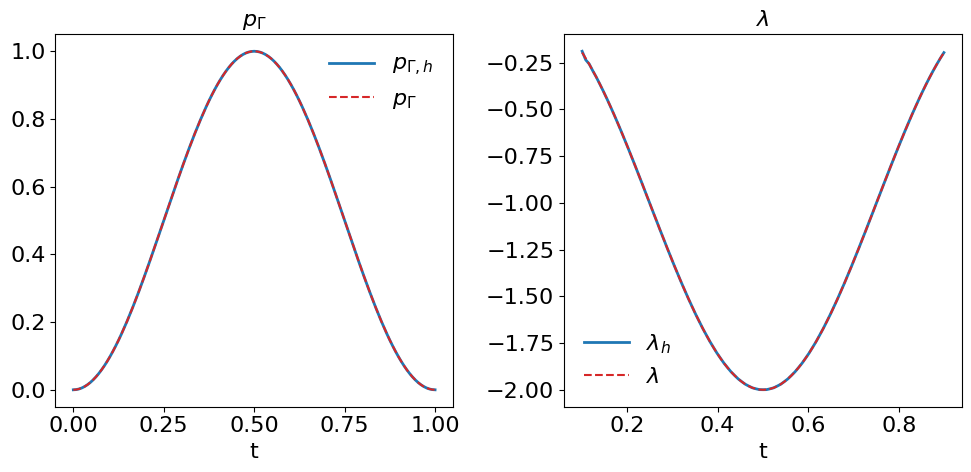

In [39]:
# ── MMS: comparison plots (FEM vs exact) ─────────────────────────────
import matplotlib.tri as mtri

# Map mesh vertices → CG1 DOF indices via coordinate lookup
dof_xy = V_m.tabulate_dof_coordinates()[:, :2]
tree_dof = cKDTree(dof_xy)
_, vert_to_dof = tree_dof.query(omega_geometry)
triangles = np.array(local_cell_vertices)   # (N_cells, 3)
triang = mtri.Triangulation(omega_geometry[:, 0], omega_geometry[:, 1], triangles)

pm_at_verts    = p_m.x.array[vert_to_dof]
pmex_at_verts  = p_m_ex.x.array[vert_to_dof]
pmerr_at_verts = np.abs(pm_at_verts - pmex_at_verts)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
vmin, vmax = min(pm_at_verts.min(), pmex_at_verts.min()), max(pm_at_verts.max(), pmex_at_verts.max())
levels = np.linspace(vmin, vmax, 21)
for ax, vals, title, cmap, lvl in [
    (axes[0], pm_at_verts,    r'$p_m$ (FEM)',               'RdBu_r', levels),
    (axes[1], pmex_at_verts,  r'$p_m$ (exact)',             'RdBu_r', levels),
    (axes[2], pmerr_at_verts, r'$|p_m^{FEM}-p_m^{ex}|$',   'Reds',   20),
]:
    cf = ax.tricontourf(triang, vals, levels=lvl, cmap=cmap)
    ax.tricontour(triang, vals, levels=lvl, colors='k', linewidths=0.3, alpha=0.4)
    ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], 'r-', lw=1.5, label=r'$\Gamma$')
    fig.colorbar(cf, ax=ax, shrink=0.85)
    ax.set_aspect('equal')
    ax.set_title(title)
plt.suptitle(r'Bulk pressure $p_m$: FEM vs exact')
plt.show()

# -- p_f and λ on fracture Γ (DOF values, sorted by parameter t) --
dof_t_f = V_f.tabulate_dof_coordinates()[:, 0]
dof_t_l = V_l.tabulate_dof_coordinates()[:, 0]
idx_f, idx_l = np.argsort(dof_t_f), np.argsort(dof_t_l)
t_f, t_l = dof_t_f[idx_f], dof_t_l[idx_l]

pf_fem  = p_f.x.array[idx_f];   pf_ex   = p_f_exact_fn(t_f)
lam_fem = lmbd.x.array[idx_l];  lam_ex_plot = lam_exact_fn(t_l)

# Tip mask for lambda: use TIP_FRAC defined in mms_verify_01
mask_l = (t_l >= TIP_FRAC) & (t_l <= 1.0 - TIP_FRAC)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(t_f, pf_fem, lw=2, color='tab:blue', label=r'$p_{\Gamma,h}$')
axes[0].plot(t_f, pf_ex,  lw=1.5, color='tab:red', linestyle='--', label=r'$p_{\Gamma}$')
axes[0].set_xlabel('t')
axes[0].set_title(r'$p_\Gamma$')
axes[0].legend(frameon=False); axes[0].grid(False)

axes[1].plot(t_l[mask_l], lam_fem[mask_l], lw=2, color='tab:blue', label=r'$\lambda_h$')
axes[1].plot(t_l[mask_l], lam_ex_plot[mask_l], lw=1.5, color='tab:red', linestyle='--', label=r'$\lambda$')
axes[1].set_xlabel('t')
axes[1].set_title(fr'$\lambda$')
axes[1].legend(frameon=False); axes[1].grid(False)

# axes[2].semilogy(t_f, np.abs(pf_fem  - pf_ex)  + 1e-16,
#                  color='tab:blue',
#                  label=r'$|p_{\Gamma,h}-p_{\Gamma}|$')
# axes[2].semilogy(t_l[mask_l], np.abs(lam_fem[mask_l] - lam_ex_plot[mask_l]) + 1e-16,
#                  color='tab:red',
#                  label=r'$|\lambda_h-\lambda|$')
# axes[2].set_xlabel('t')
# axes[2].set_title(r'Pointwise errors on $\Gamma$')
# axes[2].legend(frameon=False); axes[2].grid(False)

plt.tight_layout()
plt.show()


## 3. Ghost extension partition


physical fracture: [0. 0.] to [1. 1.] length 1.4142135623730951
ghost line: [0. 0.] to [1. 1.]
tau: [0.70710678 0.70710678] normal: [-0.70710678  0.70710678]
Note: fracture spans full domain diagonal — no ghost extension.
GHOST_START == FRAC_A, GHOST_END == FRAC_B, ghost points: 0


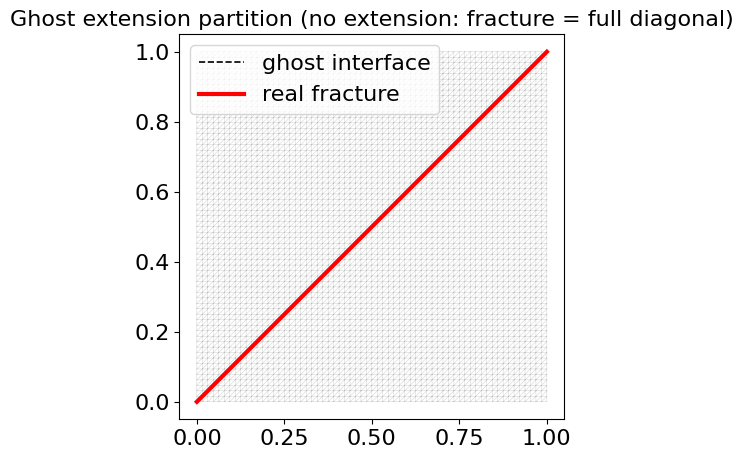

In [40]:
def unit(v):
    v = np.asarray(v, dtype=float)
    nrm = np.linalg.norm(v)
    if nrm == 0:
        raise ValueError("zero-length vector")
    return v / nrm

def extend_line_to_bbox(a, tau, bbox, tol=1e-14):
    xmin, xmax, ymin, ymax = bbox
    ts = []
    if abs(tau[0]) > tol:
        for xval in [xmin, xmax]:
            t = (xval - a[0]) / tau[0]
            y = a[1] + t * tau[1]
            if ymin - tol <= y <= ymax + tol:
                ts.append(t)
    if abs(tau[1]) > tol:
        for yval in [ymin, ymax]:
            t = (yval - a[1]) / tau[1]
            x = a[0] + t * tau[0]
            if xmin - tol <= x <= xmax + tol:
                ts.append(t)
    if len(ts) < 2:
        raise RuntimeError("Could not extend fracture line to bounding box.")
    return min(ts), max(ts)

tau_np = unit(FRAC_B - FRAC_A)
normal_np = np.array([-tau_np[1], tau_np[0]], dtype=float)
L_gamma = float(np.linalg.norm(FRAC_B - FRAC_A))
bbox = np.array([xmin, xmax, ymin, ymax], dtype=float)
t_min, t_max = extend_line_to_bbox(FRAC_A, tau_np, bbox)
GHOST_START = FRAC_A + t_min * tau_np
GHOST_END = FRAC_A + t_max * tau_np

def signed_distance_np(points):
    p = np.asarray(points, dtype=float)
    return (p[..., :2] - FRAC_A) @ normal_np

def s_coord_np(points):
    p = np.asarray(points, dtype=float)
    return (p[..., :2] - FRAC_A) @ tau_np

def real_points_np(s):
    s = np.asarray(s, dtype=float).reshape(-1)
    return FRAC_A[None, :] + s[:, None] * tau_np[None, :]

def ghost_points_np(n_each=160):
    pts = []
    if -t_min > 1e-14:
        s_left = np.linspace(t_min, 0.0, n_each, endpoint=False)
        pts.append(FRAC_A[None, :] + s_left[:, None] * tau_np[None, :])
    if t_max - L_gamma > 1e-14:
        s_right = np.linspace(L_gamma, t_max, n_each, endpoint=True)
        pts.append(FRAC_A[None, :] + s_right[:, None] * tau_np[None, :])
    return np.vstack(pts) if pts else np.zeros((0, 2))

print("physical fracture:", FRAC_A, "to", FRAC_B, "length", L_gamma)
print("ghost line:", GHOST_START, "to", GHOST_END)
print("tau:", tau_np, "normal:", normal_np)

plt.figure(figsize=(5, 5))
plt.triplot(omega_geometry[:, 0], omega_geometry[:, 1], np.array(local_cell_vertices), lw=0.25, color="0.75")
plt.plot([GHOST_START[0], GHOST_END[0]], [GHOST_START[1], GHOST_END[1]], "k--", lw=1.2, label="ghost interface")
plt.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "r-", lw=3, label="real fracture")
plt.gca().set_aspect("equal")
plt.legend()
if np.allclose(GHOST_START, FRAC_A) and np.allclose(GHOST_END, FRAC_B):
    print("Note: fracture spans full domain diagonal — no ghost extension.")
    print("GHOST_START == FRAC_A, GHOST_END == FRAC_B, ghost points:", len(ghost_points_np()))
plt.title("Ghost extension partition (no extension: fracture = full diagonal)")
plt.show()


## 4. Multiplier data and sign convention


In [41]:
# Map gamma-submesh vertices back to omega vertices, following your original notebook.
imap_g = gamma.topology.index_map(0)
num_gamma_vertices = imap_g.size_local + imap_g.num_ghosts
gamma_vertices = np.arange(num_gamma_vertices, dtype=np.int32)
gamma_to_omega_vertices = gamma_vertex_to_omega.sub_topology_to_topology(
    gamma_vertices, inverse=False
)

lmbd_bulk_vertex = np.zeros(omega.geometry.x.shape[0], dtype=float)
lmbd_bulk_vertex[gamma_to_omega_vertices] = lmbd.x.array[:len(gamma_to_omega_vertices)]

gamma_set = set(np.asarray(gamma_entities, dtype=np.int32))

# Precompute half-cell multiplier integrals from tagged physical fracture facets.
# This mirrors the /2 factor used in your original local conservation calculation.
lambda_h_cell_int_raw = np.zeros(num_cells, dtype=float)
gamma_facet_records = []

for gf in gamma_entities:
    verts = np.asarray(facet_to_vertex.links(int(gf)), dtype=np.int32)
    x0 = omega.geometry.x[verts[0], :2]
    x1 = omega.geometry.x[verts[1], :2]
    length = float(np.linalg.norm(x1 - x0))
    lam_avg = 0.5 * (lmbd_bulk_vertex[verts[0]] + lmbd_bulk_vertex[verts[1]])
    s0 = float(s_coord_np(x0[None, :])[0])
    s1 = float(s_coord_np(x1[None, :])[0])
    if s1 < s0:
        s0, s1 = s1, s0
    for cell in facet_to_cell.links(int(gf)):
        if cell < num_cells:
            lambda_h_cell_int_raw[int(cell)] += 0.5 * length * lam_avg
            gamma_facet_records.append((int(cell), s0, s1, 0.5 * length))

# Exact int(q_cg.n) via local FEniCSx assembly; int(f) via analytic MMS quadrature.
import basix
from dolfinx import mesh as dmesh

SOURCE_BARY = np.array([
    [1/3, 1/3, 1/3],
    [0.059715871789770, 0.470142064105115, 0.470142064105115],
    [0.470142064105115, 0.059715871789770, 0.470142064105115],
    [0.470142064105115, 0.470142064105115, 0.059715871789770],
    [0.797426985353087, 0.101286507323456, 0.101286507323456],
    [0.101286507323456, 0.797426985353087, 0.101286507323456],
    [0.101286507323456, 0.101286507323456, 0.797426985353087],
], dtype=float)
SOURCE_WEIGHTS = np.array([
    0.225,
    0.132394152788506,
    0.132394152788506,
    0.132394152788506,
    0.125939180544827,
    0.125939180544827,
    0.125939180544827,
], dtype=float)

def precompute_cell_flux_and_source():
    cell_flux = np.zeros(num_cells, dtype=float)
    cell_source = np.zeros(num_cells, dtype=float)
    coord_el = basix.ufl.element("Lagrange", "triangle", 1, shape=(gdim,))
    loc_cells = np.array([[0, 1, 2]], dtype=np.int64)
    dummy_coords = np.zeros((3, gdim), dtype=omega_geometry.dtype)
    local_mesh = dmesh.create_mesh(MPI.COMM_SELF, loc_cells, coord_el, dummy_coords)
    P_loc = fem.functionspace(local_mesh, ("CG", order))
    p_K = fem.Function(P_loc)
    k_K = fem.Function(P_loc)
    local_dofs = P_loc.dofmap.cell_dofs(0)
    n_K = ufl.FacetNormal(local_mesh)
    q_K = -k_K * ufl.grad(p_K)
    ds_K = ufl.ds(domain=local_mesh)
    for cell_idx, verts in enumerate(tqdm(local_cell_vertices, desc="cell q/f integrals")):
        local_mesh.geometry.x[:, :gdim] = omega_geometry[verts]
        global_dofs = V_m.dofmap.cell_dofs(cell_idx)
        p_K.x.array[local_dofs] = p_m.x.array[global_dofs]
        k_K.x.array[local_dofs] = k_m.x.array[global_dofs]
        p_K.x.scatter_forward()
        k_K.x.scatter_forward()
        cell_flux[cell_idx] = fem.assemble_scalar(fem.form(ufl.dot(q_K, n_K) * ds_K))
        qpts = SOURCE_BARY @ omega_geometry[verts]
        cell_source[cell_idx] = cell_areas[cell_idx] * np.dot(SOURCE_WEIGHTS, f_m_exact_points(qpts))
    return cell_flux, cell_source

cell_flux_cg, cell_source = precompute_cell_flux_and_source()

R_plus = cell_flux_cg - cell_source - lambda_h_cell_int_raw
R_minus = cell_flux_cg - cell_source + lambda_h_cell_int_raw
if np.mean(np.abs(R_plus)) <= np.mean(np.abs(R_minus)):
    LAMBDA_SIGN = 1.0
    lambda_h_cell_int = lambda_h_cell_int_raw
else:
    LAMBDA_SIGN = -1.0
    lambda_h_cell_int = -lambda_h_cell_int_raw

print("auto LAMBDA_SIGN:", LAMBDA_SIGN)
print("mean |R_CG| with selected sign:", np.mean(np.abs(cell_flux_cg - cell_source - lambda_h_cell_int)))
print("max  |R_CG| with selected sign:", np.max(np.abs(cell_flux_cg - cell_source - lambda_h_cell_int)))

def lambda_h_on_s(s_query):
    pts = real_points_np(np.asarray(s_query, dtype=float).reshape(-1))
    vals = eval_fem_function(lmbd, pts, gamma).reshape(-1)
    return LAMBDA_SIGN * vals


cell q/f integrals: 100%|██████████| 8192/8192 [00:55<00:00, 148.65it/s]

auto LAMBDA_SIGN: -1.0
mean |R_CG| with selected sign: 0.006325124987391918
max  |R_CG| with selected sign: 10.43150051790927


## Fracture-segment local conservation residual

For each fracture segment $e=[s_0,s_1]$, compute the 1D local balance using the flux **inside that segment**:

$$
R_e = q_{\Gamma,e}(s_1^-)-q_{\Gamma,e}(s_0^+)+\int_e \lambda_h\,ds-\int_e f_\Gamma\,ds,
\qquad q_{\Gamma,e}=-K_\Gamma\,\partial_s p_{\Gamma,h}ig|_e.
$$

So the endpoint flux is one-sided per segment, not averaged with the neighboring fracture segment. The multiplier enters with a $+$ sign exactly as assembled in the fracture block (`a_f1 = +lmbd*psi*ds`), using the **raw** solved `lmbd`. It is independent of the matrix diagnostic `LAMBDA_SIGN`, which only orients the bulk control-volume outward normal.


In [42]:
# Fracture-segment local conservation residual on Gamma.
# Run this after the lambda-sign / matrix conservation setup cell.
# Endpoint fluxes are one-sided values from the current fracture segment e.

def _lagrange_1d_values_and_derivatives(nodes, x):
    nodes = np.asarray(nodes, dtype=float).reshape(-1)
    x = float(x)
    n = len(nodes)
    if n == 1:
        return np.ones(1, dtype=float), np.zeros(1, dtype=float)
    vals = np.ones(n, dtype=float)
    ders = np.zeros(n, dtype=float)
    for i in range(n):
        for j in range(n):
            if i != j:
                vals[i] *= (x - nodes[j]) / (nodes[i] - nodes[j])
        acc = 0.0
        for m in range(n):
            if m == i:
                continue
            term = 1.0 / (nodes[i] - nodes[m])
            for j in range(n):
                if j != i and j != m:
                    term *= (x - nodes[j]) / (nodes[i] - nodes[j])
            acc += term
        ders[i] = acc
    return vals, ders


def _line_function_cells(fun):
    V = fun.function_space
    domain = V.mesh
    tdim_line = domain.topology.dim
    domain.topology.create_connectivity(tdim_line, 0)
    c2v = domain.topology.connectivity(tdim_line, 0)
    num_cells_line = domain.topology.index_map(tdim_line).size_local
    dof_coords = V.tabulate_dof_coordinates()
    cells = []
    for cid in range(num_cells_line):
        verts = np.asarray(c2v.links(cid), dtype=np.int32)
        s_verts = np.asarray(s_coord_np(domain.geometry.x[verts]), dtype=float).reshape(-1)
        s0, s1 = float(np.min(s_verts)), float(np.max(s_verts))
        dofs = np.asarray(V.dofmap.cell_dofs(cid), dtype=np.int32)
        s_nodes = np.asarray(s_coord_np(dof_coords[dofs]), dtype=float).reshape(-1)
        order = np.argsort(s_nodes)
        cells.append({
            "cell": int(cid),
            "s0": s0,
            "s1": s1,
            "dofs": dofs[order],
            "s_nodes": s_nodes[order],
        })
    cells.sort(key=lambda item: (item["s0"], item["s1"]))
    return cells


def _find_line_cell(cells, s, tol=1.0e-12):
    s = float(s)
    for cell in cells:
        if cell["s0"] - tol <= s <= cell["s1"] + tol:
            return cell
    raise ValueError(f"No fracture line cell contains s={s:.16e}")


def _eval_line_function_from_cells(fun, cells, s_query):
    s_query = np.asarray(s_query, dtype=float).reshape(-1)
    values = np.asarray(fun.x.array, dtype=float)
    out = np.empty_like(s_query, dtype=float)
    for i, s in enumerate(s_query):
        cell = _find_line_cell(cells, s)
        basis, _ = _lagrange_1d_values_and_derivatives(cell["s_nodes"], s)
        out[i] = float(np.dot(basis, values[cell["dofs"]]))
    return out


def _integrate_line_function(fun, cells, s0, s1, nq=5):
    if s1 - s0 <= 0.0:
        return 0.0
    xi, wi = np.polynomial.legendre.leggauss(int(nq))
    total = 0.0
    breakpoints = [float(s0), float(s1)]
    for cell in cells:
        if s0 < cell["s0"] < s1:
            breakpoints.append(cell["s0"])
        if s0 < cell["s1"] < s1:
            breakpoints.append(cell["s1"])
    breakpoints = np.asarray(sorted(set(np.round(breakpoints, 14))), dtype=float)
    for a, b in zip(breakpoints[:-1], breakpoints[1:]):
        if b - a <= 1.0e-14:
            continue
        sq = 0.5 * (a + b) + 0.5 * (b - a) * xi
        total += 0.5 * (b - a) * float(np.dot(wi, _eval_line_function_from_cells(fun, cells, sq)))
    return float(total)


def _fracture_source_values_on_s(s_query):
    s_query = np.asarray(s_query, dtype=float).reshape(-1)
    pts = real_points_np(s_query)
    if "f_gamma_exact_xy" in globals():
        return np.asarray(f_gamma_exact_xy(pts[:, 0], pts[:, 1]), dtype=float).reshape(-1)
    if "f_gamma_exact_fn" in globals():
        return np.asarray(f_gamma_exact_fn(pts.T), dtype=float).reshape(-1)
    if "lam_exact_fn" in globals():
        t = pts[:, 0]
        return -K_F_VALUE * np.pi**2 * np.cos(2.0 * np.pi * t) + lam_exact_fn(t)
    raise RuntimeError("No analytic fracture source helper was found.")


def _integrate_fracture_source(s0, s1, nq=8):
    if s1 - s0 <= 0.0:
        return 0.0
    xi, wi = np.polynomial.legendre.leggauss(int(nq))
    sq = 0.5 * (s0 + s1) + 0.5 * (s1 - s0) * xi
    return float(0.5 * (s1 - s0) * np.dot(wi, _fracture_source_values_on_s(sq)))


def compute_fracture_segment_residuals(nq_lambda=5, nq_source=8):
    pf_cells = _line_function_cells(p_f)
    lam_cells = _line_function_cells(lmbd)
    pvals = np.asarray(p_f.x.array, dtype=float)
    # The fracture residual block is assembled as a_f1 = +lmbd*psi*ds, so the
    # per-segment balance uses the RAW solved multiplier with a + sign. The
    # matrix-diagnostic LAMBDA_SIGN must NOT be applied here: it only orients
    # the bulk CV outward normal and is unrelated to the fracture-block sign.

    rows = []
    residuals = []
    for local_id, cell in enumerate(pf_cells):
        s0, s1 = cell["s0"], cell["s1"]
        _, dN0 = _lagrange_1d_values_and_derivatives(cell["s_nodes"], s0)
        _, dN1 = _lagrange_1d_values_and_derivatives(cell["s_nodes"], s1)
        q_e_left = -K_F_VALUE * float(np.dot(dN0, pvals[cell["dofs"]]))
        q_e_right = -K_F_VALUE * float(np.dot(dN1, pvals[cell["dofs"]]))
        flux = q_e_right - q_e_left
        lambda_int = _integrate_line_function(lmbd, lam_cells, s0, s1, nq=nq_lambda)
        source_int = _integrate_fracture_source(s0, s1, nq=nq_source)
        R_e = flux + lambda_int - source_int
        residuals.append(R_e)
        rows.append({
            "segment": local_id,
            "cell": cell["cell"],
            "s0": s0,
            "s1": s1,
            "s_mid": 0.5 * (s0 + s1),
            "q_e_left": q_e_left,
            "q_e_right": q_e_right,
            "flux_boundary": flux,
            "lambda_int": lambda_int,
            "source_int": source_int,
            "R_e": R_e,
            "abs_R_e": abs(R_e),
        })

    residuals = np.asarray(residuals, dtype=float)
    stats = {
        "n_segments": int(residuals.size),
        "mean_abs": float(np.mean(np.abs(residuals))) if residuals.size else np.nan,
        "max_abs": float(np.max(np.abs(residuals))) if residuals.size else np.nan,
    }
    return rows, residuals, stats


fracture_segment_rows, R_gamma_e, fracture_segment_stats = compute_fracture_segment_residuals()
print("Fracture-segment residual R_e = q_Gamma,e(s1-) - q_Gamma,e(s0+) + int_e lambda_h ds - int_e f_Gamma ds")
print(f"  segments     = {fracture_segment_stats['n_segments']}")
print(f"  mean |R_e|   = {fracture_segment_stats['mean_abs']:.6e}")
print(f"  max  |R_e|   = {fracture_segment_stats['max_abs']:.6e}")

try:
    import pandas as pd
    fracture_segment_residual_table = pd.DataFrame(fracture_segment_rows)
    display(fracture_segment_residual_table)
except Exception:
    fracture_segment_residual_table = fracture_segment_rows
    print(fracture_segment_rows[:5])


Fracture-segment residual R_e = q_Gamma,e(s1-) - q_Gamma,e(s0+) + int_e lambda_h ds - int_e f_Gamma ds
  segments     = 64
  mean |R_e|   = 8.142918e-02
  max  |R_e|   = 4.182233e+00


,segment,cell,s0,s1,s_mid,q_e_left,q_e_right,flux_boundary,lambda_int,source_int,R_e,abs_R_e
0,0,1,0.000000,0.022097,0.011049,-0.007002,-21.784435,-21.777433,-4.178769,-21.773970,-4.182233,4.182233
1,1,0,0.022097,0.044194,0.033146,-21.798372,-43.366077,-21.567704,-0.717205,-21.564487,-0.720423,0.720423
2,2,2,0.044194,0.066291,0.055243,-43.379812,-64.530079,-21.150267,-0.123681,-21.147540,-0.126409,0.126409
3,3,3,0.066291,0.088388,0.077340,-64.543481,-85.072622,-20.529141,-0.022405,-20.527143,-0.024404,0.024404
4,4,4,0.088388,0.110485,0.099437,-85.085560,-104.795868,-19.710308,-0.005751,-19.709271,-0.006788,0.006788
...,...,...,...,...,...,...,...,...,...,...,...,...
59,59,59,1.303728,1.325825,1.314777,104.795868,85.085560,-19.710308,-0.002147,-19.709271,-0.003184,0.003184
60,60,60,1.325825,1.347922,1.336874,85.072622,64.543481,-20.529141,-0.001402,-20.527143,-0.003401,0.003401
61,61,61,1.347922,1.370019,1.358971,64.530079,43.379812,-21.150267,-0.001267,-21.147540,-0.003994,0.003994
62,62,62,1.370019,1.392116,1.381068,43.366077,21.798372,-21.567704,-0.003723,-21.564487,-0.006940,0.006940


## 5. Interface target: lambda_h or CG flux jump


CONSERVATION_TARGET: lambda_h  (no change to lambda_h_cell_int)


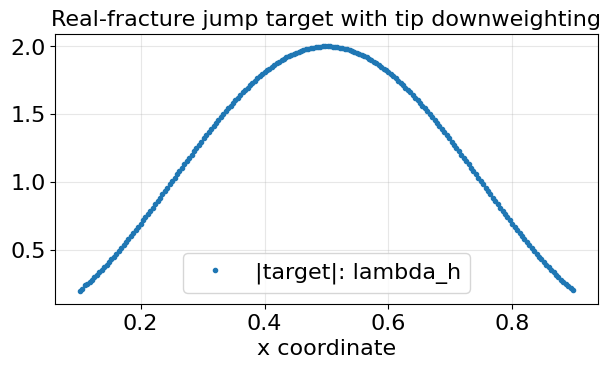

In [43]:
TARGET_MODE = "lambda_h"          # options: "lambda_h" or "cg_jump"
CONSERVATION_TARGET = "lambda_h"  # options: "lambda_h" or "cg_jump"
TIP_RADIUS_FACTOR = 10.0

def cg_jump_on_fracture(s_query, eps=None):
    if eps is None:
        eps = 0.1 * h_est
    s_query = np.asarray(s_query, dtype=float).reshape(-1)
    x0 = real_points_np(s_query)
    qp = q_cg_numpy(x0 + eps * normal_np[None, :])
    qm = q_cg_numpy(x0 - eps * normal_np[None, :])
    return np.sum((qp - qm) * normal_np[None, :], axis=1)

N_REAL = max(128, 4 * len(gamma_entities))
s_real = np.linspace(0.0, L_gamma, N_REAL)
x_real = real_points_np(s_real)
x_ghost = ghost_points_np(n_each=max(64, N_REAL // 2))

if TARGET_MODE == "lambda_h":
    lambda_target = lambda_h_on_s(s_real)
elif TARGET_MODE == "cg_jump":
    lambda_target = cg_jump_on_fracture(s_real)
else:
    raise ValueError("TARGET_MODE must be 'lambda_h' or 'cg_jump'.")

def tip_weight_np(s):
    s = np.asarray(s, dtype=float)
    d = np.minimum(s, L_gamma - s)
    radius = TIP_RADIUS_FACTOR * h_est
    return np.clip(d / max(radius, 1e-14), 0.0, 1.0)

w_tip = tip_weight_np(s_real)
x_coords = x_real[:, 0]  # real spatial x-coordinate along the fracture
t_real = x_real[:, 0]    # equals the fracture parameter t for Gamma={(t,t)}
# Same tip-exclusion mask as the lambda/flux-jump comparison, evaluated on this plot grid.
mask_cmp = (t_real >= TIP_FRAC) & (t_real <= 1.0 - TIP_FRAC)

# Recompute lambda_h_cell_int based on CONSERVATION_TARGET.
# Default MMS setting keeps lambda_h, which is the accurate LCG variable here.
if CONSERVATION_TARGET == "cg_jump":
    # Batch all facet midpoints into a single cg_jump_on_fracture call to avoid
    # vector DG single-point shape ambiguity.
    s_mids = np.array([0.5 * (s0 + s1) for _, s0, s1, _ in gamma_facet_records])
    cg_vals = cg_jump_on_fracture(s_mids)
    conservation_cell_int = np.zeros(num_cells, dtype=float)
    for i, (cell_id, s0, s1, half_length) in enumerate(gamma_facet_records):
        conservation_cell_int[int(cell_id)] += half_length * cg_vals[i]
    lambda_h_cell_int = conservation_cell_int
    print("CONSERVATION_TARGET: CG flux jump  -> lambda_h_cell_int updated")
elif CONSERVATION_TARGET == "lambda_h":
    print("CONSERVATION_TARGET: lambda_h  (no change to lambda_h_cell_int)")
else:
    raise ValueError("CONSERVATION_TARGET must be 'lambda_h' or 'cg_jump'.")

plt.figure(figsize=(7, 3.5))
# plt.semilogy(x_coords[mask_cmp], np.abs(lambda_target[mask_cmp]) + 1e-16, "o", ms=3, label=f"|target|: {TARGET_MODE}")
plt.plot(x_coords[mask_cmp], lambda_target[mask_cmp] + 1e-16, "o", ms=3, label=f"|target|: {TARGET_MODE}")
# plt.plot(x_coords, w_tip * np.max(np.abs(lambda_target) + 1e-16), "--", label="tip weight (scaled)")
plt.xlabel("x coordinate")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.title("Real-fracture jump target with tip downweighting")
plt.show()


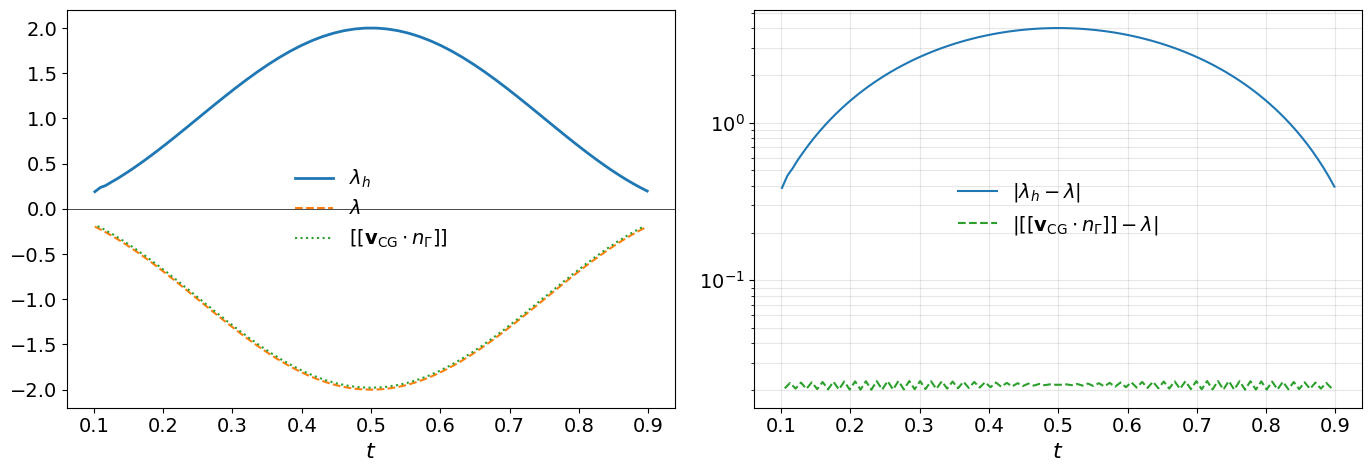

L2 err  lambda_h           (excl. 10% tips): 2.448e+00
L2 err  [[q_cg*n]] midpts  (excl. 10% tips): 1.923e-02

Sign: lambda = <<K grad p . n_gamma>> = [[q_m . n_Gamma]] = -2*alpha*sin^2(pi*t) < 0


/tmp/ipykernel_2464281/3882842173.py:64: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  l2_lh    = np.sqrt(np.trapz((lam_h_cmp[mask_cmp]   - lam_ex_cmp[mask_cmp])**2, t_in))
/tmp/ipykernel_2464281/3882842173.py:66: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  l2_cg    = np.sqrt(np.trapz((cg_jump_mid[mask_mid] - lam_ex_mid[mask_mid])**2, t_in_mid))


In [44]:
# ── Lambda / flux-jump comparison (paper: λ = ⟦K∇p·n_γ⟧ = [[q_m·n_Γ]] < 0) ──
dof_t_l_cmp = V_l.tabulate_dof_coordinates()[:, 0]
idx_l_cmp   = np.argsort(dof_t_l_cmp)
t_l_cmp     = dof_t_l_cmp[idx_l_cmp]

# FEM λ_h with sign correction (on DOF vertex grid)
lam_h_cmp  = LAMBDA_SIGN * lmbd.x.array[idx_l_cmp]

# Exact: λ = ⟦K∇p·n_γ⟧ = [[q_m·n_Γ]] = -2α sin²(πt)  (NEGATIVE, on vertex grid)
lam_ex_cmp = lam_exact_fn(t_l_cmp)   # = -2α sin²(πt)

# CG Darcy-flux jump at edge MIDPOINTS (not DOF vertices).
# At a DOF vertex the ε-offset can land in an off-diagonal triangle,
# underestimating the jump; midpoints always land in fracture-adjacent elements.
t_mid       = 0.5 * (t_l_cmp[:-1] + t_l_cmp[1:])   # between consecutive DOF positions
s_mid       = t_mid * np.sqrt(2.0)                   # arc-length coordinate
cg_jump_mid = cg_jump_on_fracture(s_mid)              # [[q_cg·n_Γ]] at midpoints
lam_ex_mid  = lam_exact_fn(t_mid)                    # λ_exact at midpoints

mask_cmp = (t_l_cmp >= TIP_FRAC) & (t_l_cmp <= 1.0 - TIP_FRAC)
mask_mid = (t_mid   >= TIP_FRAC) & (t_mid   <= 1.0 - TIP_FRAC)

fs_label = 16
fs_title = 17
fs_tick = 14
fs_legend = 14
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── left: curves ─────────────────────────────────────────────────────
axes[0].plot(t_l_cmp[mask_cmp], lam_h_cmp[mask_cmp],
             lw=2, color='C0', label=r'$\lambda_h$')
axes[0].plot(t_l_cmp[mask_cmp], lam_ex_cmp[mask_cmp],
             lw=1.5, ls='--', color='C1',
             label=r'$\lambda$')
axes[0].plot(t_mid[mask_mid], cg_jump_mid[mask_mid],
             lw=1.5, ls=':', color='C2',
             label=r'$[[\mathbf{v}_{\rm CG}\cdot n_\Gamma]]$')
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_xlabel(r'$t$', fontsize=fs_label)
# axes[0].set_title(r'$\lambda,\ [[\mathbf{v}_{\rm CG}\cdot n_\Gamma]]$', fontsize=fs_title)
axes[0].tick_params(axis='both', labelsize=fs_tick)
axes[0].legend(fontsize=fs_legend, frameon=False)
axes[0].grid(False)

# ── right: errors vs λ_exact ─────────────────────────────────────────
axes[1].semilogy(t_l_cmp[mask_cmp],
                 np.abs(lam_h_cmp[mask_cmp]   - lam_ex_cmp[mask_cmp]) + 1e-16,
                 lw=1.5, color='C0', label=r'$|\lambda_h - \lambda|$')
axes[1].semilogy(t_mid[mask_mid],
                 np.abs(cg_jump_mid[mask_mid] - lam_ex_mid[mask_mid]) + 1e-16,
                 lw=1.5, ls='--', color='C2',
                 label=r'$|[[\mathbf{v}_{\rm CG}\cdot n_\Gamma]] - \lambda|$')
axes[1].set_xlabel(r'$t$', fontsize=fs_label)
# axes[1].set_title(r'$|\cdot-\lambda|$', fontsize=fs_title)
axes[1].tick_params(axis='both', labelsize=fs_tick)
axes[1].legend(fontsize=fs_legend, frameon=False)
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

# ── L2 errors ─────────────────────────────────────────────────────────
t_in     = t_l_cmp[mask_cmp]
l2_lh    = np.sqrt(np.trapz((lam_h_cmp[mask_cmp]   - lam_ex_cmp[mask_cmp])**2, t_in))
t_in_mid = t_mid[mask_mid]
l2_cg    = np.sqrt(np.trapz((cg_jump_mid[mask_mid] - lam_ex_mid[mask_mid])**2, t_in_mid))
print(f'L2 err  lambda_h           (excl. {TIP_FRAC*100:.0f}% tips): {l2_lh:.3e}')
print(f'L2 err  [[q_cg*n]] midpts  (excl. {TIP_FRAC*100:.0f}% tips): {l2_cg:.3e}')
print()
print('Sign: lambda = <<K grad p . n_gamma>> = [[q_m . n_Gamma]] = -2*alpha*sin^2(pi*t) < 0')


## 5b. CG flux-informed split diagnostic

This diagnostic keeps the PINN setup unchanged.  It tests a facetwise proportional split
\[
\int_e \lambda_h\,ds \longmapsto
 a_e\int_e \lambda_h\,ds,\qquad (1-a_e)\int_e \lambda_h\,ds,
\]
with \(0\leq a_e\leq 1\).  The active choice below is flux-informed: \(a_e\) is computed from the magnitudes of the one-sided CG normal fluxes on the conforming fracture edge.  The reference case \(a_e=1/2\) is the current equal split; the residual-minimizing formula is left only as a commented diagnostic reference.


CG flux-informed split diagnostic
  fracture facets grouped: 64
  flux-informed two-cell facets: 64
  skipped non-two-cell facets: 0
  max |equal rebuild - current equal split| = 0.000e+00
  a_e^flux range: [0.500, 0.500], mean 0.500
  max |a_e^flux - 1/2| = 6.961e-14
  max ||F_+| - |F_-|| = 4.108e-15
  max |B_+ - B_-| = 4.385e-15
All cells, equal split:
  mean |R_K| = 6.493e-03
  max  |R_K| = 1.043e+01
All cells, flux-informed split:
  mean |R_K| = 6.493e-03
  max  |R_K| = 1.043e+01
Fracture-adjacent cells, equal split:
  mean |R_K| = 4.147e-01
  max  |R_K| = 1.043e+01
Fracture-adjacent cells, flux-informed split:
  mean |R_K| = 4.147e-01
  max  |R_K| = 1.043e+01


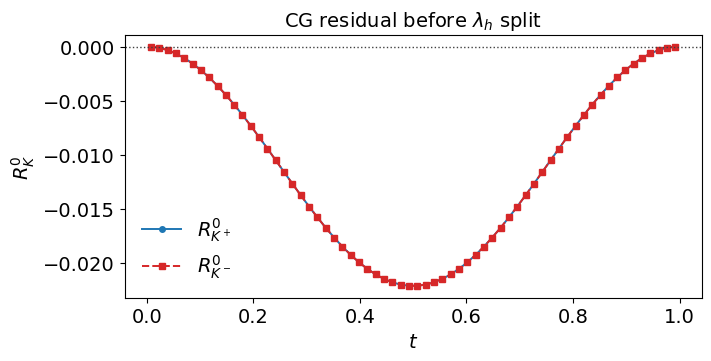

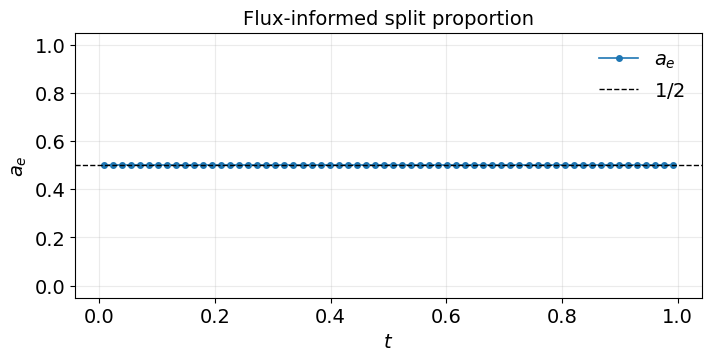

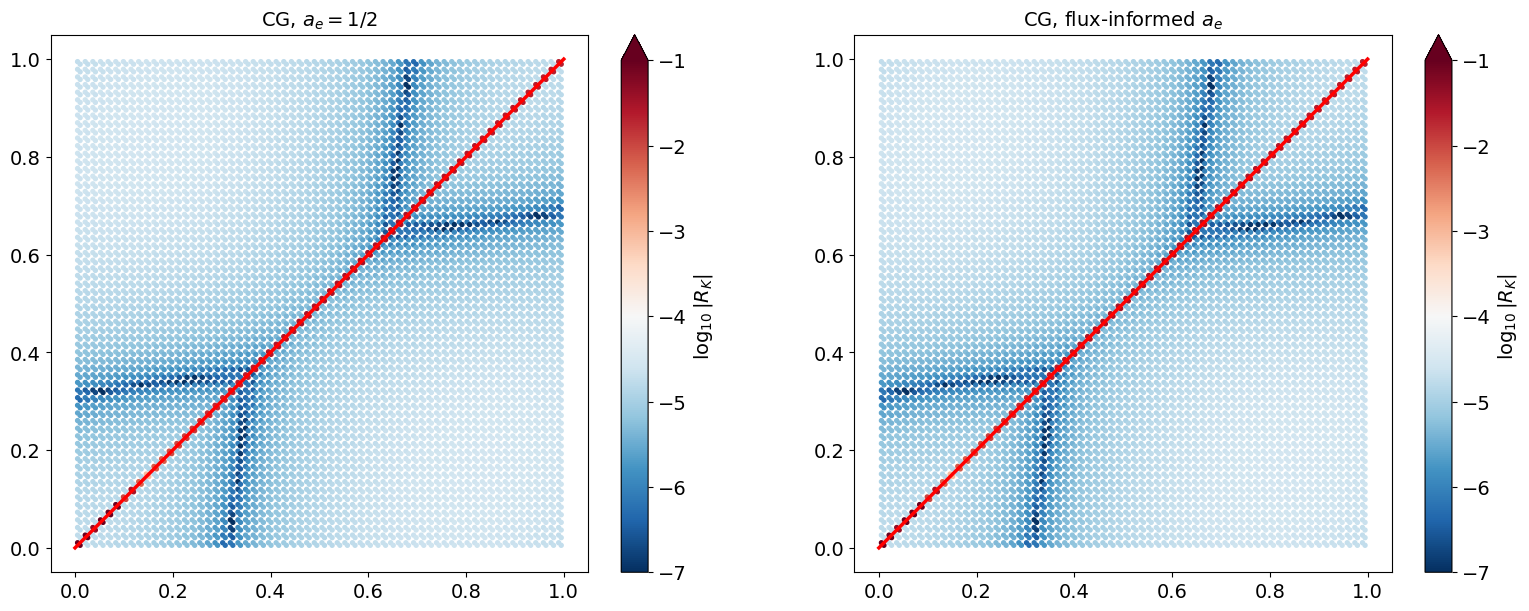

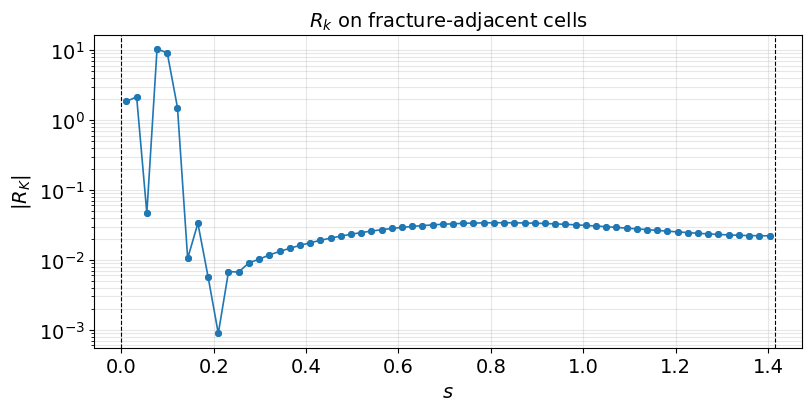

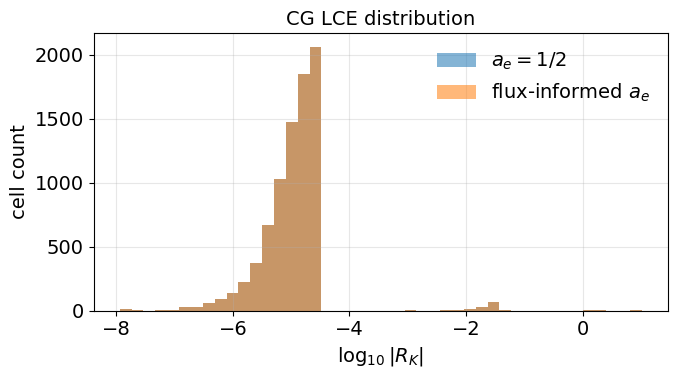

In [45]:
# ── CG-only diagnostic: flux-informed proportional split ────────────────
# This cell does not modify lambda_h_cell_int used by the PINN cells below.
# It only builds diagnostic arrays with *_diag names.

lce_eps_diag = 1e-16
# Common residual-map scale used for conforming/nonconforming comparison.
# Values outside [10^{-7}, 10^{-1}] are intentionally saturated so the colorbars match.
RK_LOG_VMIN = -7.0
RK_LOG_VMAX = -1.0
RK_CBAR_TICKS = np.array([-7, -6, -5, -4, -3, -2, -1], dtype=float)
all_cell_ids_diag = np.arange(num_cells, dtype=np.int32)
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})


_cg_elem_diag = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, order)


def _tab_diag(elem, nderiv, pts):
    t = elem.tabulate(nderiv, np.atleast_2d(pts))
    return t[..., 0] if t.ndim == 4 else t


def q_cg_owner_cell_diag(points, owner_cells):
    """Evaluate the one-sided CG flux from the prescribed owner cell."""
    points = np.asarray(points, dtype=float)
    owner_cells = np.asarray(owner_cells, dtype=np.int32)
    out = np.zeros((len(points), 2), dtype=float)
    for i, (x, ci) in enumerate(zip(points, owner_cells)):
        ci = int(ci)
        verts = local_cell_vertices[ci]
        coords = omega_geometry[verts]
        J = np.column_stack((coords[1] - coords[0], coords[2] - coords[0]))
        invJ = np.linalg.inv(J)
        xi = invJ @ (x - coords[0])
        t_s = _tab_diag(_cg_elem_diag, 1, xi)
        ref_g = np.stack([t_s[1, 0], t_s[2, 0]], axis=1)
        grad_uh = (ref_g @ invJ).T @ p_m.x.array[V_m.dofmap.cell_dofs(ci)]
        out[i] = -K_M_VALUE * grad_uh
    return out


def build_cg_edge_quadrature_for_cells_diag(cell_ids, lambda_cell_int):
    xi = np.array([0.5 * (1 - 1 / np.sqrt(3)), 0.5 * (1 + 1 / np.sqrt(3))], dtype=float)
    wi = np.array([0.5, 0.5], dtype=float)
    edge_points, edge_nw, edge_cells = [], [], []
    is_gamma_edge = []
    source, lambda_h_int = [], []
    eps_side = 1e-10

    for local_i, cell_id in enumerate(cell_ids):
        cell_id = int(cell_id)
        poly = cell_polys[cell_id]
        centroid = cell_centroids[cell_id]
        source.append(cell_source[cell_id])
        lambda_h_int.append(lambda_cell_int[cell_id])

        for j in range(len(poly)):
            x0 = poly[j]
            x1 = poly[(j + 1) % len(poly)]
            edge = x1 - x0
            n_len = np.array([edge[1], -edge[0]], dtype=float)

            for q, w in zip(xi, wi):
                pt = x0 + q * edge
                phi_pt = signed_distance_np(pt[None, :])[0]
                s_pt = s_coord_np(pt[None, :])[0]
                on_gamma = (abs(phi_pt) < 1e-12) and (-1e-12 <= s_pt <= L_gamma + 1e-12)

                # For fracture-edge quadrature, offset only for side identification.
                # The CG local conservation residual below excludes these gamma-edge samples.
                if on_gamma:
                    d = centroid - pt
                    pt = pt + eps_side * d / (np.linalg.norm(d) + 1e-30)

                edge_points.append(pt)
                edge_nw.append(w * n_len)
                edge_cells.append(local_i)
                is_gamma_edge.append(on_gamma)

    return {
        "cell_ids": np.asarray(cell_ids, dtype=np.int32),
        "edge_points": np.asarray(edge_points),
        "edge_nw": np.asarray(edge_nw),
        "edge_cells": np.asarray(edge_cells, dtype=np.int64),
        "is_gamma_edge": np.asarray(is_gamma_edge, dtype=bool),
        "source": np.asarray(source, dtype=float),
        "lambda_h_int": np.asarray(lambda_h_int, dtype=float),
    }


def cg_residual_from_split_diag(lambda_cell_int):
    data = build_cg_edge_quadrature_for_cells_diag(all_cell_ids_diag, lambda_cell_int)
    active = ~data["is_gamma_edge"]
    owner_cells = data["cell_ids"][data["edge_cells"][active]]
    q_edges = q_cg_owner_cell_diag(data["edge_points"][active], owner_cells)
    edge_flux = np.sum(q_edges * data["edge_nw"][active], axis=1)
    flux_non_gamma = np.zeros(len(data["source"]), dtype=float)
    np.add.at(flux_non_gamma, data["edge_cells"][active], edge_flux)
    R = flux_non_gamma - data["source"] - data["lambda_h_int"]
    return data, R, flux_non_gamma


# Corrected CG balance with the current equal split, using only non-gamma edges.
cg_diag_data, R_cg_equal_diag, cg_flux_non_gamma_diag = cg_residual_from_split_diag(lambda_h_cell_int)
B_cg_diag = cg_flux_non_gamma_diag - cell_source

# Group the two adjacent-cell records for each fracture facet.
edge_groups_diag = {}
for cell_id, s0, s1, half_length in gamma_facet_records:
    key = (round(float(s0), 12), round(float(s1), 12))
    edge_groups_diag.setdefault(key, []).append((int(cell_id), float(s0), float(s1), float(half_length)))

# Use the same signed facet integrals as the existing conservation target.
# This keeps the equal-split baseline identical to lambda_h_cell_int.
edge_integral_diag = {}
for gf in gamma_entities:
    verts = np.asarray(facet_to_vertex.links(int(gf)), dtype=np.int32)
    x0 = omega.geometry.x[verts[0], :2]
    x1 = omega.geometry.x[verts[1], :2]
    length = float(np.linalg.norm(x1 - x0))
    lam_avg = 0.5 * (lmbd_bulk_vertex[verts[0]] + lmbd_bulk_vertex[verts[1]])
    s0 = float(s_coord_np(x0[None, :])[0])
    s1 = float(s_coord_np(x1[None, :])[0])
    if s1 < s0:
        s0, s1 = s1, s0
    key = (round(float(s0), 12), round(float(s1), 12))
    edge_integral_diag[key] = LAMBDA_SIGN * length * lam_avg


def cg_flux_on_cell_segment_diag(cell_id, x0_seg, x1_seg):
    """One-sided CG flux integral on a fracture segment using the cell's outward normal."""
    cell_id = int(cell_id)
    poly = cell_polys[cell_id]
    centroid = cell_centroids[cell_id]
    x0_seg = np.asarray(x0_seg, dtype=float)
    x1_seg = np.asarray(x1_seg, dtype=float)
    tol = 1e-10
    pa_use, pb_use = x0_seg, x1_seg

    for j in range(len(poly)):
        pa = poly[j]
        pb = poly[(j + 1) % len(poly)]
        same = np.linalg.norm(pa - x0_seg) < tol and np.linalg.norm(pb - x1_seg) < tol
        reverse = np.linalg.norm(pa - x1_seg) < tol and np.linalg.norm(pb - x0_seg) < tol
        if same or reverse:
            pa_use, pb_use = pa, pb
            break

    edge = pb_use - pa_use
    n_len = np.array([edge[1], -edge[0]], dtype=float)
    mid = 0.5 * (pa_use + pb_use)
    # Fallback orientation check in case the segment was not found in polygon order.
    if np.dot(n_len, centroid - mid) > 0.0:
        n_len *= -1.0

    xi = np.array([0.5 * (1 - 1 / np.sqrt(3)), 0.5 * (1 + 1 / np.sqrt(3))], dtype=float)
    wi = np.array([0.5, 0.5], dtype=float)
    pts = []
    nws = []
    for q, w in zip(xi, wi):
        pt = pa_use + q * edge
        d = centroid - pt
        pt_side = pt + 1e-10 * d / (np.linalg.norm(d) + 1e-30)
        pts.append(pt_side)
        nws.append(w * n_len)
    owner_cells = np.full(len(pts), cell_id, dtype=np.int32)
    q_vals = q_cg_owner_cell_diag(np.asarray(pts, dtype=float), owner_cells)
    return float(np.sum(q_vals * np.asarray(nws, dtype=float)))

lambda_h_cell_int_equal_rebuilt_diag = np.zeros(num_cells, dtype=float)
lambda_h_cell_int_flux_diag = np.zeros(num_cells, dtype=float)
split_rows_diag = []
skipped_edges_diag = 0

for key, records in edge_groups_diag.items():
    s0, s1 = key
    s_mid = 0.5 * (s0 + s1)

    if len(records) != 2:
        skipped_edges_diag += 1
        for cell_id, rs0, rs1, half_length in records:
            subkey = (round(float(rs0), 12), round(float(rs1), 12))
            I_e = edge_integral_diag.get(subkey, 2.0 * half_length * float(lambda_h_on_s([0.5 * (rs0 + rs1)])[0]))
            lambda_h_cell_int_equal_rebuilt_diag[cell_id] += 0.5 * I_e
            lambda_h_cell_int_flux_diag[cell_id] += 0.5 * I_e
        continue

    c0 = records[0][0]
    c1 = records[1][0]
    phi_pair = signed_distance_np(cell_centroids[[c0, c1]])
    if phi_pair[0] >= phi_pair[1]:
        c_plus, c_minus = c0, c1
    else:
        c_plus, c_minus = c1, c0

    I_e = edge_integral_diag.get(key)
    if I_e is None:
        length = records[0][3] + records[1][3]
        I_e = length * float(lambda_h_on_s([s_mid])[0])

    lambda_h_cell_int_equal_rebuilt_diag[c_plus] += 0.5 * I_e
    lambda_h_cell_int_equal_rebuilt_diag[c_minus] += 0.5 * I_e

    x0_edge = real_points_np([s0])[0]
    x1_edge = real_points_np([s1])[0]
    F_plus = cg_flux_on_cell_segment_diag(c_plus, x0_edge, x1_edge)
    F_minus = cg_flux_on_cell_segment_diag(c_minus, x0_edge, x1_edge)
    flux_weight_sum = abs(F_plus) + abs(F_minus)
    if flux_weight_sum > 1e-14:
        a_e = abs(F_plus) / flux_weight_sum
    else:
        a_e = 0.5

    # Residual-minimizing split kept only as a diagnostic reference:
    # if abs(I_e) > 1e-14:
    #     a_resid = np.clip(0.5 + (B_cg_diag[c_plus] - B_cg_diag[c_minus]) / (2.0 * I_e), 0.0, 1.0)
    # else:
    #     a_resid = 0.5

    lambda_h_cell_int_flux_diag[c_plus] += a_e * I_e
    lambda_h_cell_int_flux_diag[c_minus] += (1.0 - a_e) * I_e

    split_rows_diag.append({
        "s0": s0,
        "s1": s1,
        "s_mid": s_mid,
        "t_mid": s_mid / L_gamma,
        "I_e": I_e,
        "a_plus": a_e,
        "F_plus": F_plus,
        "F_minus": F_minus,
        "cell_plus": c_plus,
        "cell_minus": c_minus,
        "R_plus_equal": B_cg_diag[c_plus] - 0.5 * I_e,
        "R_minus_equal": B_cg_diag[c_minus] - 0.5 * I_e,
        "R_plus_flux": B_cg_diag[c_plus] - a_e * I_e,
        "R_minus_flux": B_cg_diag[c_minus] - (1.0 - a_e) * I_e,
    })

R_cg_flux_diag = B_cg_diag - lambda_h_cell_int_flux_diag
frac_cell_ids_diag = np.unique([cell_id for cell_id, _, _, _ in gamma_facet_records]).astype(np.int32)

split_t_diag = np.array([row["t_mid"] for row in split_rows_diag], dtype=float)
split_a_diag = np.array([row["a_plus"] for row in split_rows_diag], dtype=float)
split_F_plus_diag = np.array([row["F_plus"] for row in split_rows_diag], dtype=float)
split_F_minus_diag = np.array([row["F_minus"] for row in split_rows_diag], dtype=float)

sort_split_diag = np.argsort(split_t_diag)
split_t_diag = split_t_diag[sort_split_diag]
split_a_diag = split_a_diag[sort_split_diag]
split_F_plus_diag = split_F_plus_diag[sort_split_diag]
split_F_minus_diag = split_F_minus_diag[sort_split_diag]
split_B_plus_diag = np.array([B_cg_diag[row["cell_plus"]] for row in split_rows_diag], dtype=float)
split_B_minus_diag = np.array([B_cg_diag[row["cell_minus"]] for row in split_rows_diag], dtype=float)
split_B_plus_diag = split_B_plus_diag[sort_split_diag]
split_B_minus_diag = split_B_minus_diag[sort_split_diag]
split_B_diff_diag = split_B_plus_diag - split_B_minus_diag


def print_lce_summary_diag(name, R, ids=None):
    vals = np.asarray(R if ids is None else R[ids], dtype=float)
    print(f"{name}:")
    print(f"  mean |R_K| = {np.mean(np.abs(vals)):.3e}")
    print(f"  max  |R_K| = {np.max(np.abs(vals)):.3e}")


print("CG flux-informed split diagnostic")
print(f"  fracture facets grouped: {len(edge_groups_diag)}")
print(f"  flux-informed two-cell facets: {len(split_rows_diag)}")
print(f"  skipped non-two-cell facets: {skipped_edges_diag}")
print(f"  max |equal rebuild - current equal split| = {np.max(np.abs(lambda_h_cell_int_equal_rebuilt_diag - lambda_h_cell_int)):.3e}")
if len(split_rows_diag):
    print(f"  a_e^flux range: [{split_a_diag.min():.3f}, {split_a_diag.max():.3f}], mean {split_a_diag.mean():.3f}")
    print(f"  max |a_e^flux - 1/2| = {np.max(np.abs(split_a_diag - 0.5)):.3e}")
    print(f"  max ||F_+| - |F_-|| = {np.max(np.abs(np.abs(split_F_plus_diag) - np.abs(split_F_minus_diag))):.3e}")
    print(f"  max |B_+ - B_-| = {np.max(np.abs(split_B_diff_diag)):.3e}")

print_lce_summary_diag("All cells, equal split", R_cg_equal_diag)
print_lce_summary_diag("All cells, flux-informed split", R_cg_flux_diag)
print_lce_summary_diag("Fracture-adjacent cells, equal split", R_cg_equal_diag, frac_cell_ids_diag)
print_lce_summary_diag("Fracture-adjacent cells, flux-informed split", R_cg_flux_diag, frac_cell_ids_diag)

# Figure 1: adjacent-cell CG base residuals before adding lambda_h.
if len(split_rows_diag):
    fig, ax = plt.subplots(figsize=(7, 3.5), constrained_layout=True)
    ax.plot(split_t_diag, split_B_plus_diag, "o-", color="tab:blue", ms=4, lw=1.4, label=r"$R^0_{K^+}$")
    ax.plot(split_t_diag, split_B_minus_diag, "s--", color="tab:red", ms=4, lw=1.4, label=r"$R^0_{K^-}$")
    ax.axhline(0.0, color="0.25", ls=":", lw=1.0)
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$R_K^0$")
    ax.set_title(r"CG residual before $\lambda_h$ split")
    ax.tick_params(axis="both", labelsize=14)
    ax.xaxis.label.set_size(14)
    ax.yaxis.label.set_size(14)
    ax.title.set_size(14)
    ax.legend(frameon=False, fontsize=14)
    plt.show()

# Figure 2: flux-informed proportion along Gamma.
if len(split_rows_diag):
    fig, ax = plt.subplots(figsize=(7, 3.5), constrained_layout=True)
    ax.plot(split_t_diag, split_a_diag, "o-", ms=4, lw=1.2, label=r"$a_e$")
    ax.axhline(0.5, color="k", ls="--", lw=1.0, label=r"$1/2$")
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$a_e$")
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(r"Flux-informed split proportion")
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False)
    plt.show()

# Figure 2: residual maps, Section-10 style, CG only.
cent_diag = cell_centroids
log_equal_diag = np.log10(np.abs(R_cg_equal_diag) + lce_eps_diag)
log_flux_diag = np.log10(np.abs(R_cg_flux_diag) + lce_eps_diag)
vmin_diag = RK_LOG_VMIN
vmax_diag = RK_LOG_VMAX
extend_diag = "max" if max(log_equal_diag.max(), log_flux_diag.max()) > RK_LOG_VMAX else "neither"

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
for ax, R, title in [
    (axes[0], R_cg_equal_diag, r"CG, $a_e=1/2$"),
    (axes[1], R_cg_flux_diag, r"CG, flux-informed $a_e$"),
]:
    sc = ax.scatter(
        cent_diag[:, 0], cent_diag[:, 1],
        c=np.log10(np.abs(R) + lce_eps_diag),
        s=8, cmap="RdBu_r", vmin=vmin_diag, vmax=vmax_diag,
    )
    ax.plot([GHOST_START[0], GHOST_END[0]], [GHOST_START[1], GHOST_END[1]], "k--", lw=1)
    ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "r-", lw=2.5)
    ax.set_aspect("equal")
    ax.set_title(title)
    cbar = fig.colorbar(sc, ax=ax, label=r"$\log_{10}|R_K|$", extend=extend_diag)
    cbar.set_ticks(RK_CBAR_TICKS)
plt.show()

# Figure 3: fracture-adjacent residuals, Section-13 style, CG only.
s_frac_diag = s_coord_np(cell_centroids[frac_cell_ids_diag])
idx_frac_diag = np.argsort(s_frac_diag)
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.semilogy(s_frac_diag[idx_frac_diag], np.abs(R_cg_equal_diag[frac_cell_ids_diag][idx_frac_diag]) + lce_eps_diag,
            "o-", ms=4, lw=1.2, label=r"$a_e=1/2$")
# ax.semilogy(s_frac_diag[idx_frac_diag], np.abs(R_cg_flux_diag[frac_cell_ids_diag][idx_frac_diag]) + lce_eps_diag,
#             "s-", ms=4, lw=1.2, label=r"flux-informed $a_e$")
ax.axvline(0.0, color="k", ls="--", lw=0.8)
ax.axvline(L_gamma, color="k", ls="--", lw=0.8)
ax.set_xlabel(r"$s$")
ax.set_ylabel(r"$|R_K|$")
ax.set_title(r"$R_k$ on fracture-adjacent cells")
ax.grid(True, which="both", alpha=0.3)
# ax.legend(frameon=False)
plt.show()

# Figure 4: distribution over all cells, CG only.
lo_diag = min(np.log10(np.abs(R_cg_equal_diag) + lce_eps_diag).min(),
              np.log10(np.abs(R_cg_flux_diag) + lce_eps_diag).min())
hi_diag = max(np.log10(np.abs(R_cg_equal_diag) + lce_eps_diag).max(),
              np.log10(np.abs(R_cg_flux_diag) + lce_eps_diag).max())
bins_diag = np.linspace(lo_diag, hi_diag, 45)
plt.figure(figsize=(7, 4))
plt.hist(np.log10(np.abs(R_cg_equal_diag) + lce_eps_diag), bins=bins_diag, alpha=0.55, label=r"$a_e=1/2$")
plt.hist(np.log10(np.abs(R_cg_flux_diag) + lce_eps_diag), bins=bins_diag, alpha=0.55, label=r"flux-informed $a_e$")
plt.xlabel(r"$\log_{10}|R_K|$")
plt.ylabel("cell count")
plt.grid(True, alpha=0.3)
plt.legend(frameon=False)
plt.title("CG LCE distribution")
plt.tight_layout()
plt.show()



### One-edge split illustration

The following cell visualizes one representative conforming fracture edge and the two adjacent elements. It is only a schematic/diagnostic figure: it does not change the conservation target used later by the PINN reconstruction.


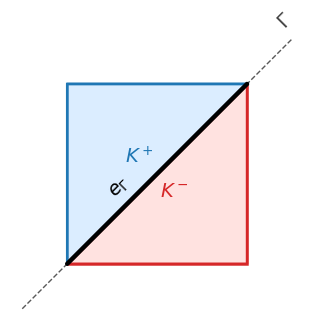

In [46]:
# ── One-edge visualization of lambda_h split between K+ and K- ─────────
# Run after the CG proportional split diagnostic cell.
EDGE_T_TARGET = 0.5  # choose the fracture edge closest to this parameter value

if not split_rows_diag:
    raise RuntimeError("Run the CG proportional split diagnostic before this visualization.")

row_edge = min(split_rows_diag, key=lambda row: abs(row["t_mid"] - EDGE_T_TARGET))
s0_edge = float(row_edge["s0"])
s1_edge = float(row_edge["s1"])
s_mid_edge = float(row_edge["s_mid"])
t_mid_edge = float(row_edge["t_mid"])
a_edge = float(row_edge["a_plus"])
I_edge = float(row_edge["I_e"])
c_plus_edge = int(row_edge["cell_plus"])
c_minus_edge = int(row_edge["cell_minus"])

x0_edge = real_points_np([s0_edge])[0]
x1_edge = real_points_np([s1_edge])[0]
xmid_edge = real_points_np([s_mid_edge])[0]
cent_plus_edge = cell_centroids[c_plus_edge]
cent_minus_edge = cell_centroids[c_minus_edge]

fig, ax = plt.subplots(figsize=(3.2, 3.2), constrained_layout=True)

poly_plus = cell_polys[c_plus_edge]
poly_minus = cell_polys[c_minus_edge]
for poly, face, edge in [
    (poly_plus, "#d9ecff", "#1f77b4"),
    (poly_minus, "#ffe1df", "#d62728"),
]:
    closed = np.vstack([poly, poly[0]])
    ax.fill(poly[:, 0], poly[:, 1], color=face, ec=edge, lw=1.8, alpha=0.95, zorder=2)
    ax.plot(closed[:, 0], closed[:, 1], color=edge, lw=1.8, zorder=3)

# Show Gamma as a thin reference line and highlight the selected conforming edge e_Gamma.
edge_vec = x1_edge - x0_edge
gamma_ref0 = x0_edge - 0.25 * edge_vec
gamma_ref1 = x1_edge + 0.25 * edge_vec
edge_angle = np.degrees(np.arctan2(edge_vec[1], edge_vec[0]))
ax.plot([gamma_ref0[0], gamma_ref1[0]], [gamma_ref0[1], gamma_ref1[1]], color="0.35", ls="--", lw=1.0, zorder=4)
ax.plot([x0_edge[0], x1_edge[0]], [x0_edge[1], x1_edge[1]], color="black", lw=3.2, solid_capstyle="round", zorder=5)

ax.text(*(xmid_edge + 0.58 * (cent_plus_edge - xmid_edge)), r"$K^+$", color="#1f77b4",
        fontsize=14, ha="center", va="center", weight="bold", zorder=6)
ax.text(*(xmid_edge + 0.58 * (cent_minus_edge - xmid_edge)), r"$K^-$", color="#d62728",
        fontsize=14, ha="center", va="center", weight="bold", zorder=6)
ax.text(*(xmid_edge - 0.14 * edge_vec + 0.13 * h_est * normal_np), r"$e_\Gamma$", color="black",
        fontsize=14, ha="center", va="center", rotation=edge_angle, zorder=7)
ax.text(*(gamma_ref1 + 0.08 * h_est * normal_np), r"$\Gamma$", color="0.25", fontsize=14,
        ha="center", va="bottom", rotation=edge_angle, zorder=7)

pad = 0.45 * h_est
pts = np.vstack([poly_plus, poly_minus])
ax.set_xlim(pts[:, 0].min() - pad, pts[:, 0].max() + pad)
ax.set_ylim(pts[:, 1].min() - pad, pts[:, 1].max() + pad)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
plt.show()


## 6. Neural flux model


In [47]:
class AdaptiveTanh(nn.Module):
    def __init__(self, n=5.0):
        super().__init__()
        self.a = nn.Parameter(torch.tensor(1.0 / n))
    def forward(self, x):
        return torch.tanh(self.a * x)

class FluxNet(nn.Module):
    def __init__(self, in_dim=2, out_dim=2, hidden_dim=64, num_hidden_layers=4, n=5.0):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), AdaptiveTanh(n=n)]
        for _ in range(num_hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), AdaptiveTanh(n=n)]
        layers.append(nn.Linear(hidden_dim, out_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)
    def slope_recovery_term(self):
        slopes = [m.a for m in self.net if isinstance(m, AdaptiveTanh)]
        return 1.0 / torch.mean(torch.exp(torch.stack(slopes)))

xy_center_np = np.array([(xmin + xmax) / 2.0, (ymin + ymax) / 2.0], dtype=float)
xy_scale = float(max(xmax - xmin, ymax - ymin))

xy_center_t = torch.tensor(xy_center_np, dtype=torch.float32, device=device)
tau_t        = torch.tensor(tau_np,       dtype=torch.float32, device=device)
normal_t     = torch.tensor(normal_np,    dtype=torch.float32, device=device)
frac_a_t     = torch.tensor(FRAC_A,      dtype=torch.float32, device=device)

def to_torch(x, requires_grad=False):
    t = torch.as_tensor(np.asarray(x, dtype=np.float32), device=device)
    if requires_grad:
        t = t.clone().detach().requires_grad_(True)
    return t

def normalize_xy(x):
    return (x - xy_center_t) / xy_scale

q_plus_net = FluxNet(hidden_dim=32, num_hidden_layers=3).to(device)
q_minus_net = FluxNet(hidden_dim=32, num_hidden_layers=3).to(device)

def signed_distance_torch(x):
    return (x - frac_a_t) @ normal_t

def s_coord_torch(x):
    return (x - frac_a_t) @ tau_t

def q_plus(x):
    return q_plus_net(normalize_xy(x))

def q_minus(x):
    return q_minus_net(normalize_xy(x))

def q_piecewise(x):
    phi = signed_distance_torch(x)
    qp = q_plus(x)
    qm = q_minus(x)
    return torch.where((phi >= 0.0).reshape(-1, 1), qp, qm)

def div_of_q(net_fn, x):
    x = x.clone().detach().requires_grad_(True)
    q = net_fn(x)
    dq0 = torch.autograd.grad(q[:, 0].sum(), x, create_graph=True)[0][:, 0]
    dq1 = torch.autograd.grad(q[:, 1].sum(), x, create_graph=True)[0][:, 1]
    return dq0 + dq1


## 7. Training data


In [48]:
N_PTS_PER_EDGE = 3  # sample points per mesh edge (interior, excluding vertices)
MASK_FACTOR_START = 0.15
MASK_FACTOR_END = 1.15

# Flux data at edge sample points, away from the fracture.
num_facets = omega.topology.index_map(fdim).size_local
edge_sample_pts = []
for f in range(num_facets):
    verts = facet_to_vertex.links(f)
    x0 = omega_geometry[verts[0]]
    x1 = omega_geometry[verts[1]]
    ts = np.linspace(0.0, 1.0, N_PTS_PER_EDGE + 2)[1:-1]
    for t in ts:
        edge_sample_pts.append(x0 + t * (x1 - x0))
edge_sample_pts = np.array(edge_sample_pts, dtype=float)

phi_edge = signed_distance_np(edge_sample_pts)
Q_data_all = q_cg_numpy(edge_sample_pts)
valid = np.all(np.isfinite(Q_data_all), axis=1)
X_data = edge_sample_pts[valid]
Q_data = Q_data_all[valid]
phi_data = phi_edge[valid]
data_mask = np.abs(phi_data) > MASK_FACTOR_START * h_est
data_mask_final = np.abs(phi_data) > MASK_FACTOR_END * h_est

X_data_t = to_torch(X_data)
Q_data_t = to_torch(Q_data)
data_idx_start_t = torch.tensor(np.nonzero(data_mask)[0], dtype=torch.long, device=device)
data_idx_final_t = torch.tensor(np.nonzero(data_mask_final)[0], dtype=torch.long, device=device)

# Divergence collocation pool. During training, div_mask widens with data_mask
# as the fracture-conservation weights ramp up.
X_div = cell_centroids
phi_div = signed_distance_np(X_div)
div_mask = np.abs(phi_div) > MASK_FACTOR_START * h_est
div_mask_final = np.abs(phi_div) > MASK_FACTOR_END * h_est
F_div = f_numpy(X_div)
X_div_t = to_torch(X_div)
F_div_t = to_torch(F_div)
div_idx_start_t = torch.tensor(np.nonzero(div_mask)[0], dtype=torch.long, device=device)
div_idx_final_t = torch.tensor(np.nonzero(div_mask_final)[0], dtype=torch.long, device=device)
side_div_t = signed_distance_torch(X_div_t) >= 0.0

# Interface tensors.
X_real_t = to_torch(x_real)
Lambda_target_t = to_torch(lambda_target)
W_tip_t = to_torch(w_tip)
X_ghost_t = to_torch(x_ghost)

print(f"flux data pool (edge-sampled, {N_PTS_PER_EDGE} pts/edge):", len(X_data))
print(f"data_mask points ({MASK_FACTOR_START:.2f}h -> {MASK_FACTOR_END:.2f}h):", np.count_nonzero(data_mask), "->", np.count_nonzero(data_mask_final))
print("div collocation pool:", len(X_div))
print(f"div_mask points ({MASK_FACTOR_START:.2f}h -> {MASK_FACTOR_END:.2f}h):", np.count_nonzero(div_mask), "->", np.count_nonzero(div_mask_final))
print("real interface points:", len(x_real))
print("ghost interface points:", len(x_ghost))

# Helper functions for post-training diagnostics and fracture-adjacent conservation loss.
def build_edge_quadrature_for_cells(cell_ids):
    xi = np.array([0.5 * (1 - 1 / np.sqrt(3)), 0.5 * (1 + 1 / np.sqrt(3))], dtype=float)
    wi = np.array([0.5, 0.5], dtype=float)
    edge_points, edge_nw, edge_cells = [], [], []
    is_gamma_edge = []  # True for quadrature points on the physical fracture edge
    source, cg_flux, lambda_h_int = [], [], []
    local_id_of_cell = {}
    eps_side = 1e-10  # offset fracture-edge points toward centroid so phi != 0
    for local_i, cell_id in enumerate(cell_ids):
        local_id_of_cell[int(cell_id)] = local_i
        poly = cell_polys[int(cell_id)]
        centroid = cell_centroids[int(cell_id)]
        source.append(cell_source[int(cell_id)])
        cg_flux.append(cell_flux_cg[int(cell_id)])
        lambda_h_int.append(lambda_h_cell_int[int(cell_id)])
        for j in range(len(poly)):
            x0 = poly[j]
            x1 = poly[(j + 1) % len(poly)]
            edge = x1 - x0
            n_len = np.array([edge[1], -edge[0]], dtype=float)
            for q, w in zip(xi, wi):
                pt = x0 + q * edge
                phi_pt = signed_distance_np(pt[None, :])[0]
                s_pt = s_coord_np(pt[None, :])[0]
                on_gamma = (abs(phi_pt) < 1e-12) and (-1e-12 <= s_pt <= L_gamma + 1e-12)
                # If pt lies exactly on gamma (phi=0), q_piecewise always
                # picks q+. Offset toward the element centroid so the point
                # lands on the correct side (K+ uses q+, K- uses q-).
                if on_gamma:
                    d = centroid - pt
                    pt = pt + eps_side * d / (np.linalg.norm(d) + 1e-30)
                edge_points.append(pt)
                edge_nw.append(w * n_len)
                edge_cells.append(local_i)
                is_gamma_edge.append(on_gamma)
    return {
        "cell_ids": np.asarray(cell_ids, dtype=np.int32),
        "edge_points": np.asarray(edge_points),
        "edge_nw": np.asarray(edge_nw),
        "edge_cells": np.asarray(edge_cells, dtype=np.int64),
        "is_gamma_edge": np.asarray(is_gamma_edge, dtype=bool),
        "source": np.asarray(source),
        "cg_flux": np.asarray(cg_flux),
        "lambda_h_int": np.asarray(lambda_h_int),
        "local_id_of_cell": local_id_of_cell,
    }

def attach_gamma_facets_to_cell_data(data):
    gamma_cell_local, gamma_s0, gamma_s1, gamma_half_length = [], [], [], []
    local_id_of_cell = data["local_id_of_cell"]
    for cell_id, s0, s1, half_length in gamma_facet_records:
        if cell_id in local_id_of_cell:
            gamma_cell_local.append(local_id_of_cell[cell_id])
            gamma_s0.append(s0)
            gamma_s1.append(s1)
            gamma_half_length.append(half_length)
    data["gamma_cell_local"] = np.asarray(gamma_cell_local, dtype=np.int64)
    data["gamma_s0"] = np.asarray(gamma_s0, dtype=float)
    data["gamma_s1"] = np.asarray(gamma_s1, dtype=float)
    data["gamma_half_length"] = np.asarray(gamma_half_length, dtype=float)
    return data


flux data pool (edge-sampled, 3 pts/edge): 37248
data_mask points (0.15h -> 1.15h): 37056 -> 35910
div collocation pool: 8192
div_mask points (0.15h -> 1.15h): 8192 -> 7938
real interface points: 256
ghost interface points: 0


## 8. Train


In [49]:
W_DATA      = 5.0
W_DIV       = 1.0
W_CONS_INT  = 1.0     # final interior fracture-adjacent conservation weight after ramp
W_CONS_TIP  = 1.0     # final tip fracture-adjacent conservation weight after ramp
CONS_INT_BETA = 1.0   # target: |R_PINN| <= beta * |R_CG| away from tips
CONS_R_FLOOR = 1e-5   # normalization floor for very small CG residuals
CONS_INT_GAMMA = 4.0  # extra penalty multiplier when PINN residual exceeds beta*CG
W_JUMP      = 1.0
W_GHOST     = 2.0
W_SLOPE     = 1e-4

EPOCHS = 5000
CONS_RAMP_START_FRAC = 0.60
CONS_RAMP_END_FRAC   = 0.90
CONS_RAMP_START = int(CONS_RAMP_START_FRAC * EPOCHS)
CONS_RAMP_END   = int(CONS_RAMP_END_FRAC   * EPOCHS)
BEST_START_EPOCH = CONS_RAMP_END
LR_PLUS  = 2e-3
LR_MINUS = 2e-3
PRINT_EVERY = 250

BATCH_DATA = 8192   # flux data points sampled per step
BATCH_DIV  = 4096   # div collocation points per step

# Precompute edge quadrature for fracture-adjacent cells (used in conservation loss).
_frac_cids = np.unique([cid for cid, _, _, _ in gamma_facet_records])
_frac_quad = build_edge_quadrature_for_cells(_frac_cids)
N_frac_cons = len(_frac_cids)
frac_eq_pts_t      = to_torch(_frac_quad["edge_points"])
frac_eq_nw_t       = to_torch(_frac_quad["edge_nw"])
frac_eq_cells_t    = torch.tensor(_frac_quad["edge_cells"],    dtype=torch.long, device=device)
frac_eq_is_gamma_t = torch.tensor(_frac_quad["is_gamma_edge"], dtype=torch.bool, device=device)
frac_source_t      = to_torch(_frac_quad["source"])
frac_lambda_t      = to_torch(_frac_quad["lambda_h_int"])
# Non-fracture-edge indices (precomputed once; mask is fixed).
nf_mask          = ~frac_eq_is_gamma_t
frac_eq_pts_nf   = frac_eq_pts_t[nf_mask]
frac_eq_nw_nf    = frac_eq_nw_t[nf_mask]
frac_eq_cells_nf = frac_eq_cells_t[nf_mask]

# Same corrected residual for CG, evaluated on the same non-fracture-edge quadrature.
_nf_np = ~_frac_quad["is_gamma_edge"]
_q_cg_nf = q_cg_numpy(_frac_quad["edge_points"][_nf_np])
_flux_cg_q = np.sum(_q_cg_nf * _frac_quad["edge_nw"][_nf_np], axis=1)
_flux_cg_K = np.zeros(N_frac_cons, dtype=float)
np.add.at(_flux_cg_K, _frac_quad["edge_cells"][_nf_np], _flux_cg_q)
frac_R_cg_np = _flux_cg_K - _frac_quad["source"] - _frac_quad["lambda_h_int"]
frac_R_cg_t = to_torch(frac_R_cg_np)

# Split the conservation objective: interior must improve CG, tips are bounded separately.
frac_s_np = s_coord_np(cell_centroids[_frac_cids])
frac_cons_tip_np = (frac_s_np < TIP_FRAC * L_gamma) | (frac_s_np > (1.0 - TIP_FRAC) * L_gamma)
frac_cons_int_np = ~frac_cons_tip_np
frac_cons_tip_t = torch.tensor(frac_cons_tip_np, dtype=torch.bool, device=device)
frac_cons_int_t = torch.tensor(frac_cons_int_np, dtype=torch.bool, device=device)
print(f"fracture-adjacent cells for conservation loss: {N_frac_cons}")
print(f"  total quad pts: {len(frac_eq_pts_t)},  non-fracture-edge pts: {nf_mask.sum().item()}")
print(f"  interior cells: {np.count_nonzero(frac_cons_int_np)},  tip cells: {np.count_nonzero(frac_cons_tip_np)}")
print(f"curriculum: conservation ramp epochs {CONS_RAMP_START}-{CONS_RAMP_END}; data_mask/div_mask switch at epoch {CONS_RAMP_START}: {MASK_FACTOR_START:.2f}h -> {MASK_FACTOR_END:.2f}h; best tracked from epoch {BEST_START_EPOCH}")

optimizer_plus  = torch.optim.Adam(q_plus_net.parameters(),  lr=LR_PLUS)
optimizer_minus = torch.optim.Adam(q_minus_net.parameters(), lr=LR_MINUS)
scheduler_plus  = torch.optim.lr_scheduler.MultiStepLR(
    optimizer_plus,
    milestones=[int(0.45 * EPOCHS), int(0.75 * EPOCHS)],
    gamma=0.35,
)
scheduler_minus = torch.optim.lr_scheduler.MultiStepLR(
    optimizer_minus,
    milestones=[int(0.45 * EPOCHS), int(0.75 * EPOCHS)],
    gamma=0.35,
)

n_data = len(X_data_t)
n_div  = len(X_div_t)

def mse(x):
    return torch.mean(x ** 2)

def smoothstep01(t):
    t = float(np.clip(t, 0.0, 1.0))
    return t * t * (3.0 - 2.0 * t)

def curriculum_for_epoch(epoch):
    if CONS_RAMP_END <= CONS_RAMP_START:
        ramp = 1.0
    else:
        t = (epoch - CONS_RAMP_START) / (CONS_RAMP_END - CONS_RAMP_START)
        ramp = smoothstep01(t)
    use_final_mask = epoch >= CONS_RAMP_START
    mask_factor = MASK_FACTOR_END if use_final_mask else MASK_FACTOR_START
    data_pool = data_idx_final_t if use_final_mask else data_idx_start_t
    div_pool = div_idx_final_t if use_final_mask else div_idx_start_t
    return ramp, mask_factor, data_pool, div_pool

def compute_loss_terms(epoch):
    cons_ramp, mask_factor, data_pool, div_pool = curriculum_for_epoch(epoch)

    # mini-batch flux data with a two-stage data_mask switch
    n_data_epoch = data_pool.numel()
    if n_data_epoch == 0:
        raise RuntimeError("data_mask removed all flux data points; reduce MASK_FACTOR_END")
    idx_d = data_pool[torch.randint(0, n_data_epoch, (min(BATCH_DATA, n_data_epoch),), device=device)]
    x_d   = X_data_t[idx_d]
    q_d   = Q_data_t[idx_d]
    loss_data = mse(q_piecewise(x_d) - q_d)

    # mini-batch div collocation with the same two-stage div_mask switch
    n_div_epoch = div_pool.numel()
    if n_div_epoch == 0:
        raise RuntimeError("div_mask removed all collocation points; reduce MASK_FACTOR_END")
    idx_v   = div_pool[torch.randint(0, n_div_epoch, (min(BATCH_DIV, n_div_epoch),), device=device)]
    x_div_b = X_div_t[idx_v]
    f_div_b = F_div_t[idx_v]
    side_b  = side_div_t[idx_v]

    div_loss = torch.tensor(0.0, device=device)
    Xp = x_div_b[side_b];  fp = f_div_b[side_b]
    Xm = x_div_b[~side_b]; fm = f_div_b[~side_b]
    if Xp.numel() > 0:
        div_loss = div_loss + mse(div_of_q(q_plus, Xp) - fp)
    if Xm.numel() > 0:
        div_loss = div_loss + mse(div_of_q(q_minus, Xm) - fm)

    # Conservation loss for fracture-adjacent elements.
    # Only non-fracture edges contribute to the flux integral;
    # the fracture acts as a source term lambda_h_int[K] on the RHS.
    # Balance: int_{e1}+int_{e2} q.n ds = int_K f dx + lambda_h_int[K]
    q_nf = q_piecewise(frac_eq_pts_nf)
    flux_q = torch.sum(q_nf * frac_eq_nw_nf, dim=1)
    flux_K = torch.zeros(N_frac_cons, device=device)
    flux_K.scatter_add_(0, frac_eq_cells_nf, flux_q)
    R_rec_frac = flux_K - frac_source_t - frac_lambda_t
    loss_cons_frac = mse(R_rec_frac)  # logged for comparison with the previous absolute loss

    loss_cons_int = torch.tensor(0.0, device=device)
    if frac_cons_int_t.any().item():
        R_rec_int = R_rec_frac[frac_cons_int_t]
        R_cg_int = frac_R_cg_t[frac_cons_int_t]
        R_cg_abs = torch.abs(R_cg_int)
        denom = torch.clamp(R_cg_abs, min=CONS_R_FLOOR)
        r_norm = R_rec_int / denom
        excess = torch.relu(torch.abs(R_rec_int) - CONS_INT_BETA * R_cg_abs)
        # base term always pushes R_K(q_theta)->0; extra term penalises when worse than CG
        loss_cons_int = torch.mean(r_norm ** 2) + CONS_INT_GAMMA * torch.mean((excess / denom) ** 2)

    loss_cons_tip = torch.tensor(0.0, device=device)
    if frac_cons_tip_t.any().item():
        loss_cons_tip = mse(R_rec_frac[frac_cons_tip_t])

    # full interface / ghost / slope (small tensors, always use all)
    qp_real = q_plus(X_real_t)
    qm_real = q_minus(X_real_t)
    jump_real = torch.sum((qp_real - qm_real) * normal_t.reshape(1, 2), dim=1)
    loss_jump = torch.mean(W_tip_t * (jump_real - Lambda_target_t) ** 2)

    loss_ghost = mse(q_plus(X_ghost_t) - q_minus(X_ghost_t)) if X_ghost_t.numel() > 0 \
                 else torch.tensor(0.0, device=device)

    loss_slope = q_plus_net.slope_recovery_term() + q_minus_net.slope_recovery_term()

    total = (
        W_DATA      * loss_data
        + W_DIV       * div_loss
        + (cons_ramp * W_CONS_INT) * loss_cons_int
        + (cons_ramp * W_CONS_TIP) * loss_cons_tip
        + W_JUMP      * loss_jump
        + W_GHOST     * loss_ghost
        + W_SLOPE     * loss_slope
    )
    parts = {
        "data":      loss_data.detach(),
        "div":       div_loss.detach(),
        "cons_frac": loss_cons_frac.detach(),
        "cons_int":  loss_cons_int.detach(),
        "cons_tip":  loss_cons_tip.detach(),
        "jump":      loss_jump.detach(),
        "ghost":     loss_ghost.detach(),
        "slope":     loss_slope.detach(),
        "cons_ramp": torch.tensor(cons_ramp, device=device),
        "mask_factor": torch.tensor(mask_factor, device=device),
        "n_data_mask": torch.tensor(float(n_data_epoch), device=device),
        "n_div_mask": torch.tensor(float(n_div_epoch), device=device),
    }
    return total, parts

history = []
best = {"loss": float("inf"), "state": None, "epoch": 0}

def snapshot_state():
    return {
        "q_plus":  {k: v.detach().cpu().clone() for k, v in q_plus_net.state_dict().items()},
        "q_minus": {k: v.detach().cpu().clone() for k, v in q_minus_net.state_dict().items()},
    }

for epoch in range(1, EPOCHS + 1):
    optimizer_plus.zero_grad(set_to_none=True)
    optimizer_minus.zero_grad(set_to_none=True)
    loss, parts = compute_loss_terms(epoch)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(q_plus_net.parameters(),  max_norm=1.0)
    torch.nn.utils.clip_grad_norm_(q_minus_net.parameters(), max_norm=1.0)
    optimizer_plus.step()
    optimizer_minus.step()
    scheduler_plus.step()
    scheduler_minus.step()

    if epoch >= BEST_START_EPOCH and float(loss.detach().cpu()) < best["loss"]:
        best["loss"] = float(loss.detach().cpu())
        best["epoch"] = epoch
        best["state"] = snapshot_state()

    if epoch == 1 or epoch % PRINT_EVERY == 0:
        row = {"epoch": epoch, "total": float(loss.detach().cpu())}
        row.update({k: float(v.cpu()) for k, v in parts.items()})
        history.append(row)
        print(
            f"{epoch:6d} total={row['total']:.3e} ramp={row['cons_ramp']:.2f} "
            f"mask={row['mask_factor']:.2f} data={row['data']:.3e} "
            f"div={row['div']:.3e} cons_int={row['cons_int']:.3e} "
            f"cons_tip={row['cons_tip']:.3e} cons_frac={row['cons_frac']:.3e} "
            f"jump={row['jump']:.3e} ghost={row['ghost']:.3e}"
        )

if best["state"] is None:
    best["loss"] = float(loss.detach().cpu())
    best["epoch"] = EPOCHS
    best["state"] = snapshot_state()

q_plus_net.load_state_dict(best["state"]["q_plus"])
q_minus_net.load_state_dict(best["state"]["q_minus"])
print("restored best epoch:", best["epoch"], "loss:", best["loss"])


fracture-adjacent cells for conservation loss: 128
  total quad pts: 768,  non-fracture-edge pts: 512
  interior cells: 104,  tip cells: 24
curriculum: conservation ramp epochs 3000-4500; data_mask/div_mask switch at epoch 3000: 0.15h -> 1.15h; best tracked from epoch 4500
     1 total=6.422e+02 ramp=0.00 mask=0.15 data=3.489e+00 div=3.824e+02 cons_int=1.554e+00 cons_tip=1.688e+01 cons_frac=3.166e+00 jump=2.424e+02 ghost=0.000e+00
   250 total=2.468e+02 ramp=0.00 mask=0.15 data=5.633e-01 div=2.828e+00 cons_int=1.290e+01 cons_tip=1.685e+01 cons_frac=3.159e+00 jump=2.412e+02 ghost=0.000e+00
   500 total=2.426e+02 ramp=0.00 mask=0.15 data=2.681e-01 div=9.868e-02 cons_int=6.989e+00 cons_tip=1.683e+01 cons_frac=3.156e+00 jump=2.412e+02 ghost=0.000e+00
   750 total=2.425e+02 ramp=0.00 mask=0.15 data=2.641e-01 div=7.636e-02 cons_int=3.508e+00 cons_tip=1.682e+01 cons_frac=3.155e+00 jump=2.411e+02 ghost=0.000e+00
  1000 total=2.425e+02 ramp=0.00 mask=0.15 data=2.603e-01 div=7.770e-02 cons_int=2

## 9. Diagnostics: local conservation and interface jump


CG local conservation:
  mean |R_K|: 0.006493495151645367
  median |R_K|: 1.2739917454420216e-05
  max  |R_K|: 10.432160277678202
Ghost-partition PINN reconstruction:
  mean |R_K|: 0.006220564890191654
  median |R_K|: 1.555266598868868e-05
  max  |R_K|: 10.434516942577096


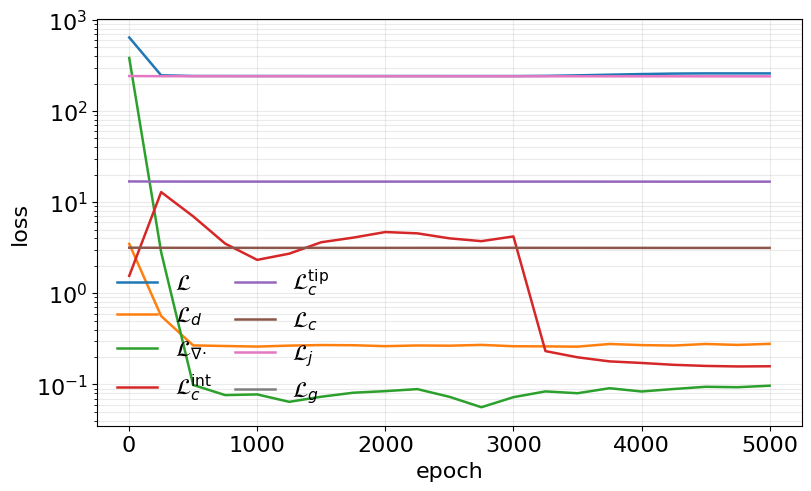

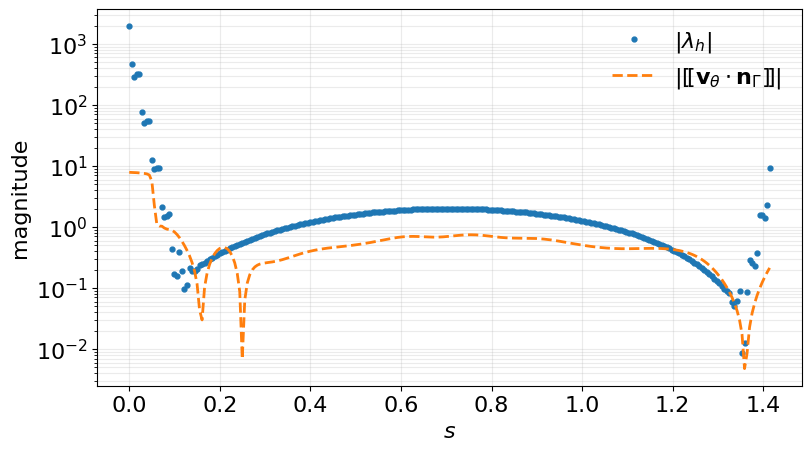

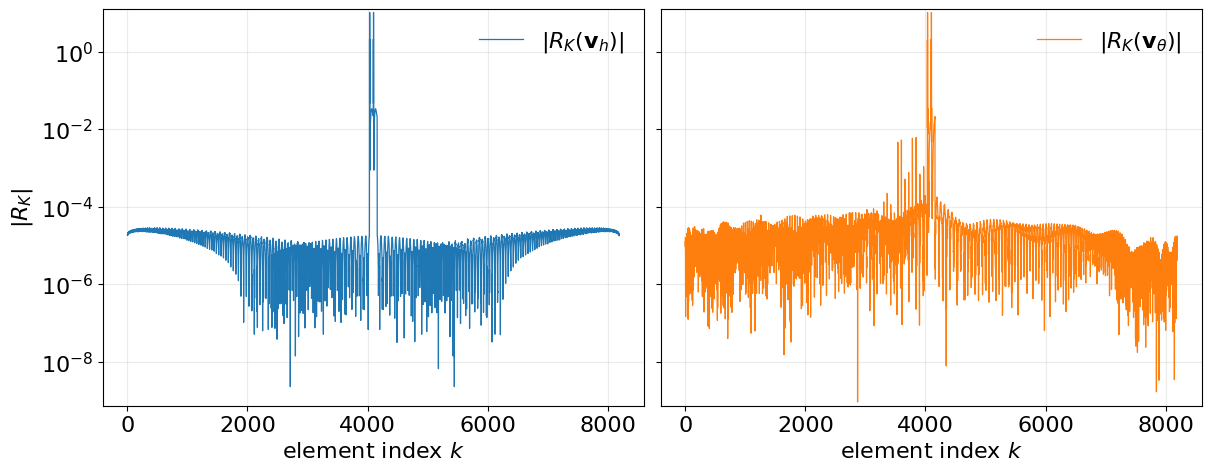

In [50]:
@torch.no_grad()
def q_rec_numpy(points):
    return q_piecewise(to_torch(points)).detach().cpu().numpy()

@torch.no_grad()
def jump_rec_numpy(s):
    xq = real_points_np(np.asarray(s, dtype=float).reshape(-1))
    return torch.sum(
        (q_plus(to_torch(xq)) - q_minus(to_torch(xq))) * normal_t.reshape(1, 2), dim=1
    ).detach().cpu().numpy()

def residual_for_cell_data_numpy(cell_ids):
    data = attach_gamma_facets_to_cell_data(build_edge_quadrature_for_cells(cell_ids))
    # Match loss_cons_frac: for fracture-adjacent cells, the fracture
    # edge is not a boundary-flux edge; lambda_h_int is the source term.
    active = ~data["is_gamma_edge"]

    q_edges_rec = q_rec_numpy(data["edge_points"][active])
    edge_flux_rec = np.sum(q_edges_rec * data["edge_nw"][active], axis=1)
    flux_rec = np.zeros(len(data["source"]))
    np.add.at(flux_rec, data["edge_cells"][active], edge_flux_rec)

    q_edges_cg = q_cg_numpy(data["edge_points"][active])
    edge_flux_cg = np.sum(q_edges_cg * data["edge_nw"][active], axis=1)
    flux_cg = np.zeros(len(data["source"]))
    np.add.at(flux_cg, data["edge_cells"][active], edge_flux_cg)

    R_rec = flux_rec - data["source"] - data["lambda_h_int"]
    R_cg  = flux_cg  - data["source"] - data["lambda_h_int"]
    return data, R_cg, R_rec

all_cell_ids = np.arange(num_cells)
diag_data, R_cg, R_rec = residual_for_cell_data_numpy(all_cell_ids)

print("CG local conservation:")
print("  mean |R_K|:", np.mean(np.abs(R_cg)))
print("  median |R_K|:", np.median(np.abs(R_cg)))
print("  max  |R_K|:", np.max(np.abs(R_cg)))
print("Ghost-partition PINN reconstruction:")
print("  mean |R_K|:", np.mean(np.abs(R_rec)))
print("  median |R_K|:", np.median(np.abs(R_rec)))
print("  max  |R_K|:", np.max(np.abs(R_rec)))

hist = {k: np.array([row[k] for row in history]) for k in history[0].keys()}

# Publication-style diagnostics.
pub_fs = 16
plt.rcParams.update({
    "font.size": pub_fs,
    "axes.labelsize": pub_fs,
    "axes.titlesize": pub_fs,
    "xtick.labelsize": pub_fs,
    "ytick.labelsize": pub_fs,
    "legend.fontsize": pub_fs,
})

# Training history.
loss_labels = {
    "total": r"$\mathcal{L}$",
    "data": r"$\mathcal{L}_d$",
    "div": r"$\mathcal{L}_{\nabla\!\cdot}$",
    "cons_int": r"$\mathcal{L}_c^{\mathrm{int}}$",
    "cons_tip": r"$\mathcal{L}_c^{\mathrm{tip}}$",
    "cons_frac": r"$\mathcal{L}_c$",
    "jump": r"$\mathcal{L}_j$",
    "ghost": r"$\mathcal{L}_g$",
}
fig, ax = plt.subplots(figsize=(8.0, 4.8), constrained_layout=True)
for key in ["total", "data", "div", "cons_int", "cons_tip", "cons_frac", "jump", "ghost"]:
    ax.semilogy(hist["epoch"], hist[key], lw=1.8, label=loss_labels[key])
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.grid(True, which="both", alpha=0.25)
ax.legend(ncol=2, frameon=False, columnspacing=1.0, handlelength=1.8)
plt.show()

# Real-fracture jump condition.
jump_rec = jump_rec_numpy(s_real)
fig, ax = plt.subplots(figsize=(8.0, 4.4), constrained_layout=True)
ax.semilogy(s_real, np.abs(lambda_target) + 1e-16, "o", ms=3.5, lw=1.2,
            label=r"$|\lambda_h|$")
ax.semilogy(s_real, np.abs(jump_rec) + 1e-16, "--", lw=2.0,
            label=r"$|[\![\mathbf{v}_\theta\cdot\mathbf{n}_\Gamma]\!]|$")
ax.set_xlabel(r"$s$")
ax.set_ylabel("magnitude")
ax.grid(True, which="both", alpha=0.25)
ax.legend(frameon=False)
plt.show()

# Element residual by index: before vs after reconstruction.
rk_eps = 1e-16
rk_cg = np.abs(R_cg) + rk_eps
rk_rec = np.abs(R_rec) + rk_eps
rk_ymin = max(rk_eps, min(np.min(rk_cg), np.min(rk_rec)) * 0.8)
rk_ymax = max(np.max(rk_cg), np.max(rk_rec)) * 1.2
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6), sharey=True, constrained_layout=True)
for ax, values, label, color in [
    (axes[0], rk_cg, r"$|R_K(\mathbf{v}_h)|$", "tab:blue"),
    (axes[1], rk_rec, r"$|R_K(\mathbf{v}_\theta)|$", "tab:orange"),
]:
    ax.semilogy(np.arange(len(values)), values, lw=0.9, color=color, label=label)
    ax.set_xlabel(r"element index $k$")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(frameon=False, loc="upper right")
    ax.set_ylim(rk_ymin, rk_ymax)
axes[0].set_ylabel(r"$|R_K|$")
plt.show()


## 10. Residual maps


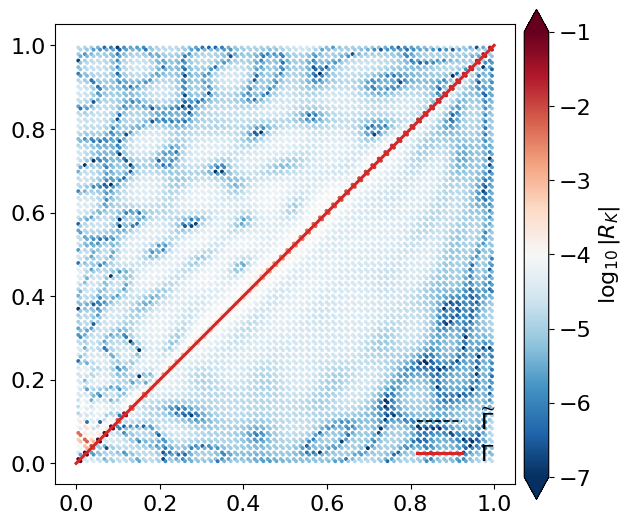

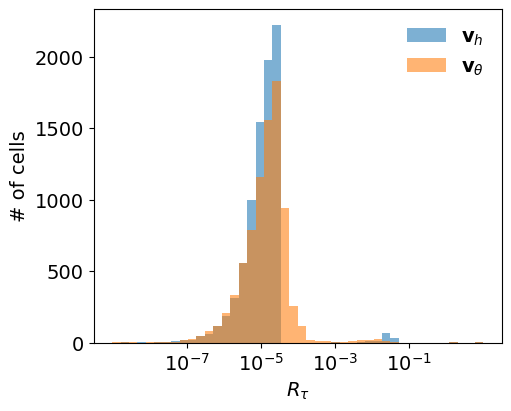

In [51]:
cent = cell_centroids[diag_data["cell_ids"]]

# Publication-style residual map after PINN reconstruction.
# The CG residual map is shown earlier in Section 5b.
# Values outside [10^{-7}, 10^{-1}] are intentionally saturated so the colorbars match.
pub_fs = 16
plt.rcParams.update({
    "font.size": pub_fs,
    "axes.labelsize": pub_fs,
    "axes.titlesize": pub_fs,
    "xtick.labelsize": pub_fs,
    "ytick.labelsize": pub_fs,
    "legend.fontsize": pub_fs,
})
rk_log_vmin = globals().get("RK_LOG_VMIN", -7.0)
rk_log_vmax = globals().get("RK_LOG_VMAX", -1.0)
rk_cbar_ticks = globals().get("RK_CBAR_TICKS", np.array([-7, -6, -5, -4, -3, -2, -1], dtype=float))
rk_log_cg = np.log10(np.abs(R_cg) + 1e-16)
rk_log_rec = np.log10(np.abs(R_rec) + 1e-16)
rk_log_min = rk_log_rec.min()
rk_log_max = rk_log_rec.max()
if rk_log_min < rk_log_vmin and rk_log_max > rk_log_vmax:
    rk_extend = "both"
elif rk_log_min < rk_log_vmin:
    rk_extend = "min"
elif rk_log_max > rk_log_vmax:
    rk_extend = "max"
else:
    rk_extend = "neither"

fig, ax = plt.subplots(figsize=(6.2, 5.2), constrained_layout=True)
sc = ax.scatter(
    cent[:, 0],
    cent[:, 1],
    c=rk_log_rec,
    s=8,
    cmap="RdBu_r",
    vmin=rk_log_vmin,
    vmax=rk_log_vmax,
    linewidths=0.0,
    rasterized=True,
)
ax.plot([GHOST_START[0], GHOST_END[0]], [GHOST_START[1], GHOST_END[1]],
        "k--", lw=1.2, label=r"$\widetilde{\Gamma}$")
ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]],
        color="tab:red", ls="-", lw=2.2, label=r"$\Gamma$")
ax.set_aspect("equal")
# ax.set_title(r"$|R_K(\mathbf{v}_\theta)|$")
# ax.set_xlabel(r"$x$")
# ax.set_ylabel(r"$y$")
ax.grid(False)
ax.legend(frameon=False, loc="lower right", handlelength=2.0)
cbar = fig.colorbar(sc, ax=ax, label=r"$\log_{10}|R_K|$", extend=rk_extend, pad=0.02)
cbar.set_ticks(rk_cbar_ticks)
plt.show()

lo = min(rk_log_cg.min(), rk_log_rec.min())
hi = max(rk_log_cg.max(), rk_log_rec.max())
bins = np.linspace(lo, hi, 45)
fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
ax.hist(rk_log_cg, bins=bins, alpha=0.58, label=r"$\mathbf{v}_h$", color="tab:blue")
ax.hist(rk_log_rec, bins=bins, alpha=0.58, label=r"$\mathbf{v}_\theta$", color="tab:orange")
ax.set_xlabel(r"$R_\tau$", fontsize=14)
rk_hist_ticks = rk_cbar_ticks[::2]
ax.set_xticks(rk_hist_ticks)
ax.set_xticklabels([r"$10^{%d}$" % int(t) for t in rk_hist_ticks])
ax.tick_params(labelsize=14)
ax.set_ylabel("# of cells", fontsize=14)
ax.grid(False)
ax.legend(frameon=False, fontsize=14)
plt.show()


Interior control-volume residual R_xi (Deng-style vertex dual cells)
CG flux $\mathbf{v}_h$
  mean |R_xi|   = 1.082861e-03
  median |R_xi| = 9.165972e-07
  max  |R_xi|   = 1.223697e+00
PINN reconstruction $\mathbf{v}_\theta$
  mean |R_xi|   = 7.371650e-04
  median |R_xi| = 3.160037e-05
  max  |R_xi|   = 1.394082e+00


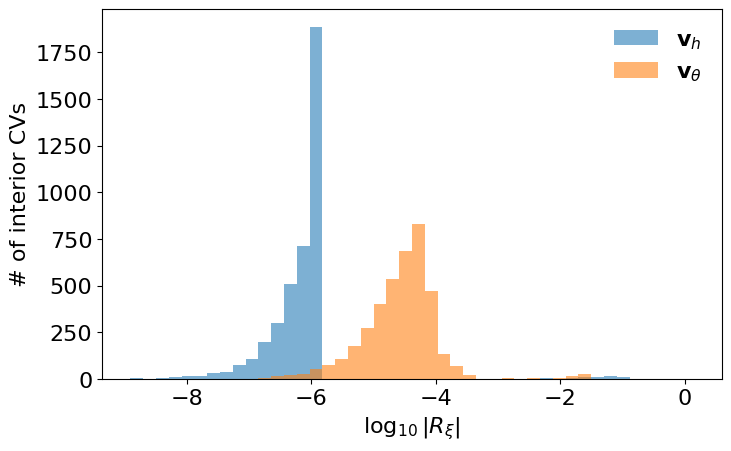

In [52]:
# Deng-style vertex control-volume residual R_xi.
def rxi_normal_from_C_to_ti(centroid, midpoint, vi):
    t = midpoint - centroid
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    seg_mid = 0.5 * (centroid + midpoint)
    chosen = n1 if np.dot(n1, vi - seg_mid) < 0.0 else n2
    return chosen / (np.linalg.norm(chosen) + 1e-30)

def rxi_point_in_convex_polygon(pt, poly, tol=1e-12):
    pt = np.asarray(pt, dtype=float)[:2]
    poly = np.asarray(poly, dtype=float)[:, :2]
    for j in range(len(poly)):
        a = poly[j]
        b = poly[(j + 1) % len(poly)]
        edge = b - a
        cross = edge[0] * (pt[1] - a[1]) - edge[1] * (pt[0] - a[0])
        if cross < -tol:
            return False
    return True

def rxi_segment_edge_s_candidates(a, b, s_min, s_max, tol=1e-12):
    a = np.asarray(a, dtype=float)[:2]
    b = np.asarray(b, dtype=float)[:2]
    edge = b - a
    A = np.column_stack((tau_np, -edge))
    rhs = a - FRAC_A
    det = np.linalg.det(A)
    if abs(det) < tol:
        if max(abs(np.dot(a - FRAC_A, normal_np)), abs(np.dot(b - FRAC_A, normal_np))) > 10.0 * tol:
            return []
        sa = float(s_coord_np(a[None, :])[0])
        sb = float(s_coord_np(b[None, :])[0])
        lo = max(min(sa, sb), s_min)
        hi = min(max(sa, sb), s_max)
        return [lo, hi] if hi - lo > tol else []
    s, u = np.linalg.solve(A, rhs)
    if s_min - tol <= s <= s_max + tol and -tol <= u <= 1.0 + tol:
        return [float(np.clip(s, s_min, s_max))]
    return []

def rxi_fracture_intervals_in_polygon(poly, s_min=0.0, s_max=None, tol=1e-11):
    poly = order_polygon_vertices(np.asarray(poly, dtype=float)[:, :2])
    if s_max is None:
        s_max = L_gamma
    s_min = max(0.0, float(s_min))
    s_max = min(float(L_gamma), float(s_max))
    if s_max - s_min <= tol:
        return []
    candidates = [s_min, s_max]
    for j in range(len(poly)):
        candidates.extend(rxi_segment_edge_s_candidates(poly[j], poly[(j + 1) % len(poly)], s_min, s_max, tol=tol))
    candidates = sorted(candidates)
    unique = []
    for s in candidates:
        if not unique or abs(s - unique[-1]) > tol:
            unique.append(float(s))
    intervals = []
    for s0, s1 in zip(unique[:-1], unique[1:]):
        if s1 - s0 <= tol:
            continue
        sm = 0.5 * (s0 + s1)
        if rxi_point_in_convex_polygon(real_points_np([sm])[0], poly, tol=1e-10):
            intervals.append((float(s0), float(s1)))
    return intervals

def rxi_integrate_lambda_interval(s0, s1):
    if s1 - s0 <= 0.0:
        return 0.0
    mid = 0.5 * (s0 + s1)
    half = 0.5 * (s1 - s0)
    sq = mid + half * np.array([-1.0 / np.sqrt(3.0), 1.0 / np.sqrt(3.0)])
    return float(half * np.sum(lambda_h_on_s(sq)))

def rxi_integrate_source_polygon(poly):
    bary = globals().get("SOURCE_BARY", globals().get("TRI_BARY"))
    weights = globals().get("SOURCE_WEIGHTS", globals().get("TRI_WEIGHTS"))
    if bary is None or weights is None:
        raise RuntimeError("No triangle source quadrature rule is available.")
    poly = order_polygon_vertices(np.asarray(poly, dtype=float)[:, :2])
    total = 0.0
    p0 = poly[0]
    for j in range(1, len(poly) - 1):
        tri = np.vstack([p0, poly[j], poly[j + 1]])
        area = abs(polygon_signed_area(tri))
        qpts = bary @ tri
        vals = np.asarray(f_m_exact_points(qpts), dtype=float).reshape(-1)
        total += area * float(np.dot(weights, vals))
    return float(total)

def build_rxi_cv_residuals():
    vertex_key_to_id = {}
    vertices_xy = []
    cell_vertex_ids = []

    def get_vid(xy):
        key = tuple(np.round(np.asarray(xy, dtype=float)[:2], 12))
        if key not in vertex_key_to_id:
            vertex_key_to_id[key] = len(vertices_xy)
            vertices_xy.append(np.asarray(xy, dtype=float)[:2])
        return vertex_key_to_id[key]

    for poly_raw in cell_polys:
        poly = order_polygon_vertices(np.asarray(poly_raw, dtype=float)[:, :2])
        cell_vertex_ids.append(np.array([get_vid(xy) for xy in poly], dtype=np.int32))

    n_vertices = len(vertices_xy)
    flux_cg = np.zeros(n_vertices, dtype=float)
    flux_rec = np.zeros(n_vertices, dtype=float)
    source = np.zeros(n_vertices, dtype=float)
    lambda_src = np.zeros(n_vertices, dtype=float)
    edge_points = []
    edge_nw = []
    edge_vids = []
    gamma_by_cell = {}
    for cell_id, s0, s1, seg_len in gamma_facet_records:
        denom = max(float(s1) - float(s0), 1e-30)
        gamma_by_cell.setdefault(int(cell_id), []).append((float(s0), float(s1), float(seg_len) / denom))

    g3 = np.array([0.1127016653792583, 0.5, 0.8872983346207417], dtype=float)
    w3 = np.array([5.0 / 18.0, 8.0 / 18.0, 5.0 / 18.0], dtype=float)
    for cell_id, poly_raw in enumerate(cell_polys):
        poly = order_polygon_vertices(np.asarray(poly_raw, dtype=float)[:, :2])
        centroid = poly.mean(axis=0)
        vids = cell_vertex_ids[cell_id]
        nloc = len(poly)
        for j, vid in enumerate(vids):
            vi = poly[j]
            mid_next = 0.5 * (vi + poly[(j + 1) % nloc])
            mid_prev = 0.5 * (vi + poly[(j - 1) % nloc])
            cv_poly = order_polygon_vertices(np.vstack([vi, mid_next, centroid, mid_prev]))
            source[vid] += rxi_integrate_source_polygon(cv_poly)
            for s0, s1, factor in gamma_by_cell.get(cell_id, []):
                for a, b in rxi_fracture_intervals_in_polygon(cv_poly, s0, s1):
                    lambda_src[vid] += factor * rxi_integrate_lambda_interval(a, b)
            for midp in (mid_next, mid_prev):
                seg = midp - centroid
                seg_len = float(np.linalg.norm(seg))
                if seg_len <= 1e-30:
                    continue
                n_unit = rxi_normal_from_C_to_ti(centroid, midp, vi)
                pts = centroid[None, :] + g3[:, None] * seg[None, :]
                nw = w3[:, None] * n_unit[None, :] * seg_len
                edge_points.append(pts)
                edge_nw.append(nw)
                edge_vids.extend([int(vid)] * len(g3))

    edge_points = np.vstack(edge_points)
    edge_nw = np.vstack(edge_nw)
    edge_vids = np.asarray(edge_vids, dtype=np.int32)
    q_cg_edge = q_cg_numpy(edge_points)
    q_rec_edge = q_rec_numpy(edge_points)
    np.add.at(flux_cg, edge_vids, np.sum(q_cg_edge * edge_nw, axis=1))
    np.add.at(flux_rec, edge_vids, np.sum(q_rec_edge * edge_nw, axis=1))
    return {
        "vertices_xy": np.asarray(vertices_xy, dtype=float),
        "cell_vertex_ids": cell_vertex_ids,
        "flux_cg": flux_cg,
        "flux_rec": flux_rec,
        "source": source,
        "lambda_src": lambda_src,
    }, flux_cg - source - lambda_src, flux_rec - source - lambda_src

def rxi_boundary_vertex_mask(vertices_xy):
    xy = np.asarray(vertices_xy, dtype=float)
    x0 = globals().get("xmin", float(xy[:, 0].min()))
    x1 = globals().get("xmax", float(xy[:, 0].max()))
    y0 = globals().get("ymin", float(xy[:, 1].min()))
    y1 = globals().get("ymax", float(xy[:, 1].max()))
    tol = 1e-12
    return (np.isclose(xy[:, 0], x0, atol=tol) | np.isclose(xy[:, 0], x1, atol=tol) |
            np.isclose(xy[:, 1], y0, atol=tol) | np.isclose(xy[:, 1], y1, atol=tol))

def rxi_print_stats(label, values, ids):
    vals = np.abs(np.asarray(values, dtype=float)[ids])
    print(label)
    print(f"  mean |R_xi|   = {np.mean(vals):.6e}")
    print(f"  median |R_xi| = {np.median(vals):.6e}")
    print(f"  max  |R_xi|   = {np.max(vals):.6e}")

rxi_data, R_xi_cg, R_xi_rec = build_rxi_cv_residuals()
rxi_is_boundary = rxi_boundary_vertex_mask(rxi_data["vertices_xy"])
rxi_interior_ids = np.where(~rxi_is_boundary)[0]

print("Interior control-volume residual R_xi (Deng-style vertex dual cells)")
rxi_print_stats(r"CG flux $\mathbf{v}_h$", R_xi_cg, rxi_interior_ids)
rxi_print_stats(r"PINN reconstruction $\mathbf{v}_\theta$", R_xi_rec, rxi_interior_ids)

rxi_log_cg = np.log10(np.abs(R_xi_cg[rxi_interior_ids]) + 1e-16)
rxi_log_rec = np.log10(np.abs(R_xi_rec[rxi_interior_ids]) + 1e-16)
lo = min(rxi_log_cg.min(), rxi_log_rec.min())
hi = max(rxi_log_cg.max(), rxi_log_rec.max())
bins = np.linspace(lo, hi, 45)
fig, ax = plt.subplots(figsize=(7.2, 4.4), constrained_layout=True)
ax.hist(rxi_log_cg, bins=bins, alpha=0.58, label=r"$\mathbf{v}_h$", color="tab:blue")
ax.hist(rxi_log_rec, bins=bins, alpha=0.58, label=r"$\mathbf{v}_\theta$", color="tab:orange")
ax.set_xlabel(r"$\log_{10}|R_\xi|$")
ax.set_ylabel("# of interior CVs")
ax.grid(False)
ax.legend(frameon=False)
plt.show()


## 11. Save model and arrays


In [53]:
import pathlib

outdir_rec = pathlib.Path("result_ghost_partition_pinn")
outdir_rec.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "q_plus":      q_plus_net.state_dict(),
        "q_minus":     q_minus_net.state_dict(),
        "FRAC_A":      FRAC_A,
        "FRAC_B":      FRAC_B,
        "GHOST_START": GHOST_START,
        "GHOST_END":   GHOST_END,
        "normal":      normal_np,
        "tau":         tau_np,
        "LAMBDA_SIGN": LAMBDA_SIGN,
        "TARGET_MODE": TARGET_MODE,
        "CONSERVATION_TARGET": CONSERVATION_TARGET,
        "xy_center":   xy_center_np,
        "xy_scale":    xy_scale,
    },
    outdir_rec / "ghost_partition_pinn_flux.pt",
)

np.savez(
    outdir_rec / "diagnostics.npz",
    cell_ids=diag_data["cell_ids"],
    centroids=cent,
    R_cg=R_cg,
    R_rec=R_rec,
    R_xi_cg=globals().get("R_xi_cg", np.array([])),
    R_xi_rec=globals().get("R_xi_rec", np.array([])),
    rxi_vertices=globals().get("rxi_data", {}).get("vertices_xy", np.zeros((0, 2))),
    rxi_interior_ids=globals().get("rxi_interior_ids", np.array([], dtype=np.int32)),
    s_real=s_real,
    lambda_target=lambda_target,
    jump_rec=jump_rec,
)

print("saved to", outdir_rec.resolve())


saved to /home/muchamad/PhD/fenicsx/code/fracture problem/result_ghost_partition_pinn


## 12. Jump diagnostics: real fracture and ghost extension

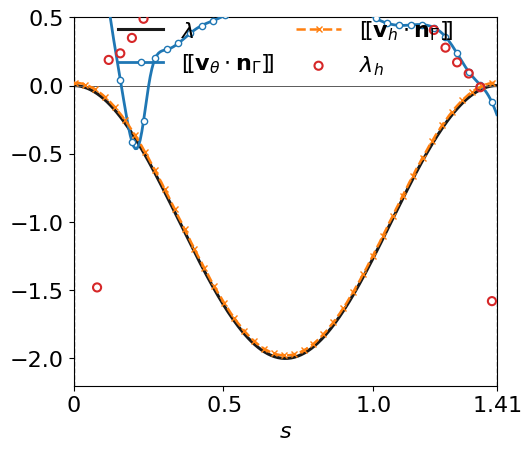

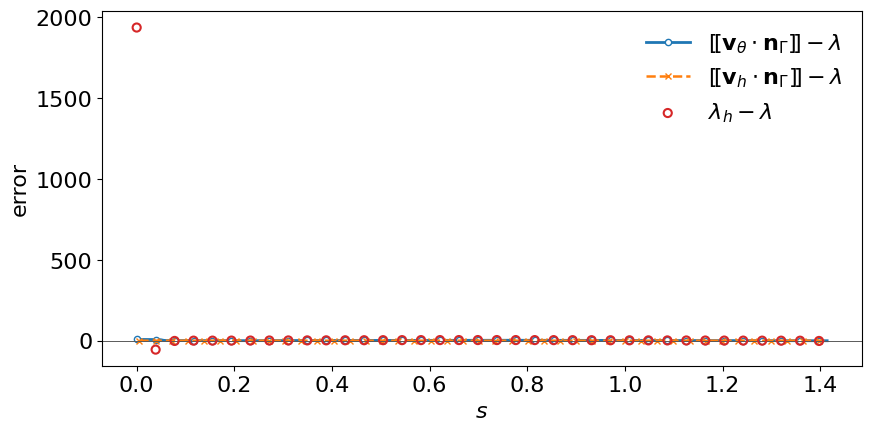

No ghost extension (fracture spans full diagonal; tips lie on the domain boundary).
Real fracture jump vs lambda_exact  (excl. 10% tips):
  PINN — max=2.731e+00  mean=1.684e+00  L2=1.991e+00
  CG   — max=2.293e-02  mean=2.161e-02  L2=2.287e-02
  lam_h— max=4.000e+00  mean=2.468e+00  L2=2.911e+00


/tmp/ipykernel_2464281/3703326270.py:156: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  PINN — max={np.max(np.abs(pinn_err)):.3e}  mean={np.mean(np.abs(pinn_err)):.3e}  L2={np.sqrt(np.trapz(pinn_err**2, s_real[mask_tip])):.3e}")
/tmp/ipykernel_2464281/3703326270.py:157: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  CG   — max={np.max(np.abs(cg_err)):.3e}  mean={np.mean(np.abs(cg_err)):.3e}  L2={np.sqrt(np.trapz(cg_err**2, s_mid_jump[mask_tip_mid])):.3e}")
/tmp/ipykernel_2464281/3703326270.py:158: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  lam_h— max={np.max(np.abs(lh_err)):.3e}  mean={np.mean(np.abs(lh_err)):.3e}  L2={np.sqrt(np.trapz(lh_err**2,   s_real[mask_tip])):.3e}")


In [54]:
@torch.no_grad()
def jump_and_sides_numpy(pts):
    x_t = to_torch(pts)
    qp = q_plus(x_t).cpu().numpy()
    qm = q_minus(x_t).cpu().numpy()
    qp_n = qp @ normal_np
    qm_n = qm @ normal_np
    return qp_n, qm_n, qp_n - qm_n

# Arc-length coordinates.
s_ghost_all   = s_coord_np(x_ghost)
mask_left     = s_ghost_all < 0.0
mask_right    = s_ghost_all > L_gamma
x_ghost_left  = x_ghost[mask_left];   s_ghost_left  = s_ghost_all[mask_left]
x_ghost_right = x_ghost[mask_right];  s_ghost_right = s_ghost_all[mask_right]

# PINN jumps.
qp_n_real, qm_n_real, jump_pinn_real = jump_and_sides_numpy(x_real)
_, _, jump_pinn_gl = jump_and_sides_numpy(x_ghost_left)  if len(x_ghost_left)  else (None, None, np.array([]))
_, _, jump_pinn_gr = jump_and_sides_numpy(x_ghost_right) if len(x_ghost_right) else (None, None, np.array([]))

# CG jumps. On the physical fracture, use edge midpoints as in Section 5.
# Evaluating the two-sided eps-offset jump at fracture vertices can sample an
# off-diagonal element and introduce artificial zig-zag oscillations.
dof_t_jump = np.sort(V_l.tabulate_dof_coordinates()[:, 0])
t_mid_jump = 0.5 * (dof_t_jump[:-1] + dof_t_jump[1:])
s_mid_jump = t_mid_jump * np.sqrt(2.0)
jump_cg_mid = cg_jump_on_fracture(s_mid_jump)
lambda_exact_mid = lam_exact_fn(t_mid_jump)
jump_cg_gl   = cg_jump_on_fracture(s_ghost_left)  if len(s_ghost_left)  else np.array([])
jump_cg_gr   = cg_jump_on_fracture(s_ghost_right) if len(s_ghost_right) else np.array([])

# lambda_h on real fracture (apply LAMBDA_SIGN for correct physical sign).
lambda_h_real = LAMBDA_SIGN * eval_fem_function(lmbd, x_real, gamma).reshape(-1)

# Exact lambda on real fracture (MMS: -2 alpha sin^2(pi t), t = x-coordinate).
t_real = x_real[:, 0]   # x-coordinate = fracture parameter t in [0, 1]
lambda_exact_real = lam_exact_fn(t_real)

# Full ghost-line arrays. CG uses midpoint sampling on the real fracture.
s_full        = np.concatenate([s_ghost_left, s_real, s_ghost_right])
s_cg_full     = np.concatenate([s_ghost_left, s_mid_jump, s_ghost_right])
jump_pinn_all = np.concatenate([jump_pinn_gl, jump_pinn_real, jump_pinn_gr])
jump_cg_all   = np.concatenate([jump_cg_gl,   jump_cg_mid,    jump_cg_gr])

# Publication-style jump diagnostics.
pub_fs = 16
plt.rcParams.update({
    "font.size": pub_fs,
    "axes.labelsize": pub_fs,
    "axes.titlesize": pub_fs,
    "xtick.labelsize": pub_fs,
    "ytick.labelsize": pub_fs,
    "legend.fontsize": pub_fs,
})
jump_label = r"$[\![\mathbf{v}\cdot\mathbf{n}_\Gamma]\!]$"
jump_theta_label = r"$[\![\mathbf{v}_\theta\cdot\mathbf{n}_\Gamma]\!]$"
jump_h_label = r"$[\![\mathbf{v}_h\cdot\mathbf{n}_\Gamma]\!]$"

# Signed jump along the ghost line.
fig, ax = plt.subplots(figsize=(5.2, 4.4), constrained_layout=True)
mark_full = max(len(s_full) // 34, 1)
mark_cg_full = max(len(s_cg_full) // 34, 1)
mark_real = max(len(s_real) // 34, 1)
ax.plot(
    s_real, lambda_exact_real,
    color="0.10", lw=2.2, ls="-", label=r"$\lambda$", zorder=2,
)
ax.plot(
    s_full, jump_pinn_all,
    color="tab:blue", lw=2.0, marker="o", ms=4.5, markevery=mark_full,
    mfc="white", mec="tab:blue", label=jump_theta_label, zorder=3,
)
ax.plot(
    s_cg_full, jump_cg_all,
    color="tab:orange", lw=1.8, ls="--", marker="x", ms=5.0, markevery=mark_cg_full,
    label=jump_h_label, zorder=3,
)
ax.scatter(
    s_real[::mark_real], lambda_h_real[::mark_real],
    s=34, facecolors="none", edgecolors="tab:red", linewidths=1.5,
    label=r"$\lambda_h$", zorder=4,
)
ax.axvline(0.0, color="k", lw=0.9, ls="--")
ax.axvline(L_gamma, color="k", lw=0.9, ls="--")
ax.axhline(0.0, color="0.35", lw=0.7)
jump_y_lo = min(lambda_exact_real.min(), lambda_h_real.min(), jump_pinn_all.min(), jump_cg_all.min())
jump_y_hi = max(lambda_exact_real.max(), lambda_h_real.max(), jump_pinn_all.max(), jump_cg_all.max())
jump_y_pad_lo = 0.08 * max(jump_y_hi - jump_y_lo, 1e-6)
ax.set_ylim(-2.2, 0.5)
ax.set_xlim(0.0, L_gamma)
ax.set_xticks([0.0, 0.5, 1.0, L_gamma])
ax.set_xticklabels([r"$0$", r"$0.5$", r"$1.0$", rf"${L_gamma:.2f}$"])
ax.set_xlabel(r"$s$")
# ax.set_ylabel(jump_label)
ax.legend(
    frameon=False, ncol=2, columnspacing=1.0, handlelength=2.0,
    loc="upper center", bbox_to_anchor=(0.5, 1.02), borderaxespad=0.0,
)
ax.grid(False)
plt.show()

# Pointwise jump error on the real fracture.
fig, ax = plt.subplots(figsize=(8.6, 4.2), constrained_layout=True)
mark_real = max(len(s_real) // 34, 1)
mark_mid = max(len(s_mid_jump) // 34, 1)
ax.plot(
    s_real, jump_pinn_real - lambda_exact_real,
    color="tab:blue", lw=2.0, marker="o", ms=4.5, markevery=mark_real,
    mfc="white", mec="tab:blue",
    label=r"$[\![\mathbf{v}_\theta\cdot\mathbf{n}_\Gamma]\!]-\lambda$",
)
ax.plot(
    s_mid_jump, jump_cg_mid - lambda_exact_mid,
    color="tab:orange", lw=1.8, ls="--", marker="x", ms=5.0, markevery=mark_mid,
    label=r"$[\![\mathbf{v}_h\cdot\mathbf{n}_\Gamma]\!]-\lambda$",
)
ax.scatter(
    s_real[::mark_real], (lambda_h_real - lambda_exact_real)[::mark_real],
    s=34, facecolors="none", edgecolors="tab:red", linewidths=1.5,
    label=r"$\lambda_h-\lambda$", zorder=4,
)
ax.axhline(0.0, color="0.35", lw=0.7)
ax.set_xlabel(r"$s$")
ax.set_ylabel("error")
ax.legend(frameon=False, ncol=1, handlelength=2.0)
ax.grid(False)
plt.show()

# Ghost-extension jump magnitude, if the ghost extension exists.
s_ghost_only   = np.concatenate([s_ghost_left, s_ghost_right])
jp_ghost_only  = np.concatenate([jump_pinn_gl, jump_pinn_gr])
jcg_ghost_only = np.concatenate([jump_cg_gl,   jump_cg_gr])

if len(s_ghost_only):
    fig, ax = plt.subplots(figsize=(8.6, 4.2), constrained_layout=True)
    ax.semilogy(s_ghost_only, np.abs(jp_ghost_only) + 1e-16,
                color="tab:blue", lw=1.8, label=r"$|[\![\mathbf{v}_\theta\cdot\mathbf{n}_\Gamma]\!]|$")
    ax.semilogy(s_ghost_only, np.abs(jcg_ghost_only) + 1e-16,
                color="tab:orange", lw=1.8, ls="--", label=r"$|[\![\mathbf{v}_h\cdot\mathbf{n}_\Gamma]\!]|$")
    ax.set_xlabel(r"$s$")
    ax.set_ylabel("magnitude")
    ax.legend(frameon=False, handlelength=2.0)
    ax.grid(True, which="both", alpha=0.22)
    plt.show()
else:
    print("No ghost extension (fracture spans full diagonal; tips lie on the domain boundary).")

# Summary numbers.
mask_tip = (s_real >= TIP_FRAC * L_gamma) & (s_real <= (1 - TIP_FRAC) * L_gamma)
mask_tip_mid = (s_mid_jump >= TIP_FRAC * L_gamma) & (s_mid_jump <= (1 - TIP_FRAC) * L_gamma)
pinn_err = jump_pinn_real[mask_tip] - lambda_exact_real[mask_tip]
cg_err   = jump_cg_mid[mask_tip_mid] - lambda_exact_mid[mask_tip_mid]
lh_err   = lambda_h_real[mask_tip]  - lambda_exact_real[mask_tip]
print(f"Real fracture jump vs lambda_exact  (excl. {TIP_FRAC*100:.0f}% tips):")
print(f"  PINN — max={np.max(np.abs(pinn_err)):.3e}  mean={np.mean(np.abs(pinn_err)):.3e}  L2={np.sqrt(np.trapz(pinn_err**2, s_real[mask_tip])):.3e}")
print(f"  CG   — max={np.max(np.abs(cg_err)):.3e}  mean={np.mean(np.abs(cg_err)):.3e}  L2={np.sqrt(np.trapz(cg_err**2, s_mid_jump[mask_tip_mid])):.3e}")
print(f"  lam_h— max={np.max(np.abs(lh_err)):.3e}  mean={np.mean(np.abs(lh_err)):.3e}  L2={np.sqrt(np.trapz(lh_err**2,   s_real[mask_tip])):.3e}")
if len(s_ghost_only):
    print(f"Ghost — max |PINN [[v·n]]|={np.max(np.abs(jp_ghost_only)):.3e}   max |CG [[v·n]]|={np.max(np.abs(jcg_ghost_only)):.3e}")


## 13. Local conservation around fracture and ghost extension


Fracture-adjacent cells: 128
Ghost extension cells   : 0


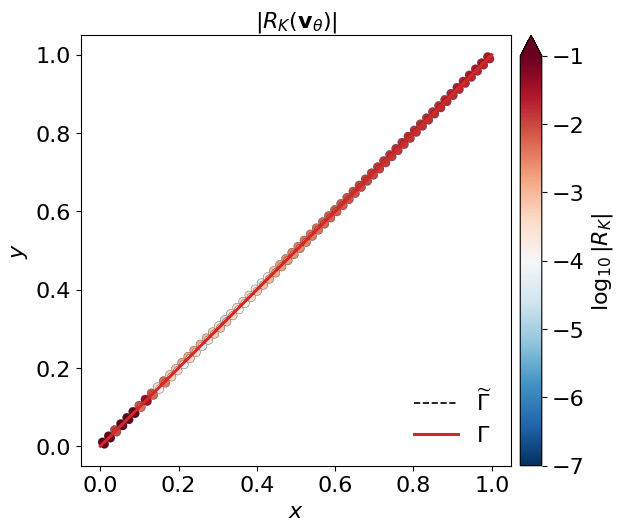

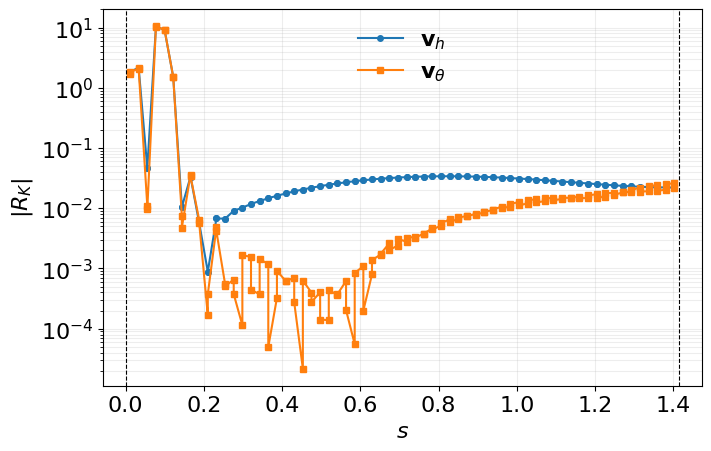


Fracture-adjacent cells  (n=128):
  CG   mean|R| = 4.147e-01   max|R| = 1.043e+01
  PINN mean|R| = 3.966e-01   max|R| = 1.043e+01

Ghost extension cells: none


In [55]:
# Identify fracture-adjacent cells.
frac_cell_ids = np.unique([cell_id for cell_id, _, _, _ in gamma_facet_records])

# Identify ghost extension cells (near ghost line, outside physical fracture).
# For the MMS full-diagonal case, this should be empty because the physical
# fracture spans the full diagonal of the bounding box.
d_ghost_thresh = 2.5 * h_est
phi_cent_all = signed_distance_np(cell_centroids)
s_cent_all   = s_coord_np(cell_centroids)
ghost_mask = (
    (np.abs(phi_cent_all) < d_ghost_thresh) &
    ((s_cent_all < 0.0) | (s_cent_all > L_gamma))
)
ghost_cell_ids = np.where(ghost_mask)[0]

# R_cg / R_rec are indexed directly by cell index (diag_data['cell_ids'] = arange).
R_cg_frac   = R_cg[frac_cell_ids]
R_rec_frac  = R_rec[frac_cell_ids]
R_cg_ghost  = R_cg[ghost_cell_ids]
R_rec_ghost = R_rec[ghost_cell_ids]

cent_frac  = cell_centroids[frac_cell_ids]
cent_ghost = cell_centroids[ghost_cell_ids]
s_frac     = s_coord_np(cent_frac)
s_ghost    = s_coord_np(cent_ghost) if len(cent_ghost) else np.array([])

print(f"Fracture-adjacent cells: {len(frac_cell_ids)}")
print(f"Ghost extension cells   : {len(ghost_cell_ids)}")

if len(ghost_cell_ids):
    all_ids   = np.concatenate([frac_cell_ids, ghost_cell_ids])
    all_cent  = cell_centroids[all_ids]
    all_R_cg  = np.concatenate([R_cg_frac, R_cg_ghost])
    all_R_rec = np.concatenate([R_rec_frac, R_rec_ghost])
else:
    all_ids   = frac_cell_ids
    all_cent  = cent_frac
    all_R_cg  = R_cg_frac
    all_R_rec = R_rec_frac

# Publication-style local residual diagnostics.
pub_fs = 16
plt.rcParams.update({
    "font.size": pub_fs,
    "axes.labelsize": pub_fs,
    "axes.titlesize": pub_fs,
    "xtick.labelsize": pub_fs,
    "ytick.labelsize": pub_fs,
    "legend.fontsize": pub_fs,
})
rk_log_vmin = globals().get("RK_LOG_VMIN", -7.0)
rk_log_vmax = globals().get("RK_LOG_VMAX", -1.0)
rk_cbar_ticks = globals().get("RK_CBAR_TICKS", np.array([-7, -6, -5, -4, -3, -2, -1], dtype=float))
rk_log_rec_local = np.log10(np.abs(all_R_rec) + 1e-16)
rk_log_min = rk_log_rec_local.min()
rk_log_max = rk_log_rec_local.max()
if rk_log_min < rk_log_vmin and rk_log_max > rk_log_vmax:
    rk_extend = "both"
elif rk_log_min < rk_log_vmin:
    rk_extend = "min"
elif rk_log_max > rk_log_vmax:
    rk_extend = "max"
else:
    rk_extend = "neither"

# Map: reconstructed residual only. The corresponding CG residual map is shown in Section 5b.
fig, ax = plt.subplots(figsize=(6.2, 5.2), constrained_layout=True)
sc = ax.scatter(
    all_cent[:, 0],
    all_cent[:, 1],
    c=rk_log_rec_local,
    s=38,
    cmap="RdBu_r",
    vmin=rk_log_vmin,
    vmax=rk_log_vmax,
    edgecolors="k",
    linewidths=0.2,
    rasterized=True,
)
ax.plot([GHOST_START[0], GHOST_END[0]], [GHOST_START[1], GHOST_END[1]],
        "k--", lw=1.2, label=r"$\widetilde{\Gamma}$")
ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]],
        color="tab:red", ls="-", lw=2.2, label=r"$\Gamma$")
ax.set_aspect("equal")
ax.set_title(r"$|R_K(\mathbf{v}_\theta)|$")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.grid(False)
ax.legend(frameon=False, loc="lower right", handlelength=2.0)
cbar = fig.colorbar(sc, ax=ax, label=r"$\log_{10}|R_K|$", extend=rk_extend, pad=0.02)
cbar.set_ticks(rk_cbar_ticks)
plt.show()

# Residuals versus arclength: keep CG and reconstructed residuals for comparison.
ncols = 2 if len(ghost_cell_ids) else 1
fig, axes = plt.subplots(1, ncols, figsize=(7.0 * ncols, 4.4), constrained_layout=True)
if ncols == 1:
    axes = [axes]

panels = [(axes[0], R_cg_frac, R_rec_frac, s_frac, "fracture-adjacent")]
if len(ghost_cell_ids):
    panels.append((axes[1], R_cg_ghost, R_rec_ghost, s_ghost, "ghost extension"))

for ax, R_cg_f, R_rec_f, s_f, label in panels:
    sort_idx = np.argsort(s_f)
    ax.semilogy(s_f[sort_idx], np.abs(R_cg_f[sort_idx]) + 1e-16,
                "o-", ms=4, lw=1.5, label=r"$\mathbf{v}_h$")
    ax.semilogy(s_f[sort_idx], np.abs(R_rec_f[sort_idx]) + 1e-16,
                "s-", ms=4, lw=1.5, label=r"$\mathbf{v}_\theta$")
    ax.axvline(0.0, color="k", ls="--", lw=0.8)
    ax.axvline(L_gamma, color="k", ls="--", lw=0.8)
    # ax.set_title(label)
    ax.set_xlabel(r"$s$")
    ax.set_ylabel(r"$|R_K|$")
    ax.grid(True, which="both", alpha=0.22)
    ax.legend(frameon=False, handlelength=2.0)
plt.show()

# Summary numbers.
for label, ids, R_cg_f, R_rec_f in [
    ("Fracture-adjacent", frac_cell_ids,  R_cg_frac,  R_rec_frac),
    ("Ghost extension",   ghost_cell_ids, R_cg_ghost, R_rec_ghost),
]:
    if len(ids) == 0:
        print(f"\n{label} cells: none")
        continue
    print(f"\n{label} cells  (n={len(ids)}):")
    print(f"  CG   mean|R| = {np.mean(np.abs(R_cg_f)):.3e}   max|R| = {np.max(np.abs(R_cg_f)):.3e}")
    print(f"  PINN mean|R| = {np.mean(np.abs(R_rec_f)):.3e}   max|R| = {np.max(np.abs(R_rec_f)):.3e}")


### Tip vs interior contribution to plateaued losses


In [56]:
# Split the plateaued training losses into near-tip and interior parts.
# This uses the same TIP_FRAC convention as the jump/LCE diagnostics above.
tip_pt = (s_real < TIP_FRAC * L_gamma) | (s_real > (1.0 - TIP_FRAC) * L_gamma)
int_pt = ~tip_pt

err_jump = jump_rec - lambda_target
jump_terms = w_tip * err_jump**2
jump_tip_contrib = np.sum(jump_terms[tip_pt]) / len(jump_terms)
jump_int_contrib = np.sum(jump_terms[int_pt]) / len(jump_terms)

print("Jump loss split (current model, same scale as logged jump loss):")
print(f"  all mean          : {np.mean(jump_terms):.3e}")
if history:
    print(f"  last logged       : {history[-1]['jump']:.3e}")
print(f"  tip contribution : {jump_tip_contrib:.3e}  (n={np.count_nonzero(tip_pt)})")
print(f"  int contribution : {jump_int_contrib:.3e}  (n={np.count_nonzero(int_pt)})")
if np.count_nonzero(tip_pt):
    print(f"  tip mean          : {np.mean(jump_terms[tip_pt]):.3e}")
if np.count_nonzero(int_pt):
    print(f"  int mean          : {np.mean(jump_terms[int_pt]):.3e}")

tip_cell = (s_frac < TIP_FRAC * L_gamma) | (s_frac > (1.0 - TIP_FRAC) * L_gamma)
int_cell = ~tip_cell

def _print_lce_split(name, R):
    R2 = R**2
    print(f"\n{name} conservation residual split:")
    print(f"  all mean(R^2)      : {np.mean(R2):.3e}")
    if np.count_nonzero(tip_cell):
        print(f"  tip contribution  : {np.sum(R2[tip_cell]) / len(R2):.3e}  (n={np.count_nonzero(tip_cell)})")
        print(f"  tip mean(R^2)      : {np.mean(R2[tip_cell]):.3e}")
        print(f"  tip max|R|         : {np.max(np.abs(R[tip_cell])):.3e}")
    if np.count_nonzero(int_cell):
        print(f"  int contribution  : {np.sum(R2[int_cell]) / len(R2):.3e}  (n={np.count_nonzero(int_cell)})")
        print(f"  int mean(R^2)      : {np.mean(R2[int_cell]):.3e}")
        print(f"  int max|R|         : {np.max(np.abs(R[int_cell])):.3e}")
    print(f"  all mean|R|        : {np.mean(np.abs(R)):.3e}")

_print_lce_split("PINN", R_rec_frac)
_print_lce_split("CG", R_cg_frac)

if np.count_nonzero(int_cell):
    R_pin_abs = np.abs(R_rec_frac[int_cell])
    R_cg_abs = np.abs(R_cg_frac[int_cell])
    ratio = R_pin_abs / np.maximum(R_cg_abs, 1e-16)
    print("\nInterior PINN-vs-CG conservation:")
    print(f"  improved cells       : {100.0 * np.mean(R_pin_abs < R_cg_abs):.1f}%")
    print(f"  mean |PINN|/|CG|    : {np.mean(ratio):.3e}")
    print(f"  median |PINN|/|CG|  : {np.median(ratio):.3e}")
    print(f"  max |PINN|/|CG|     : {np.max(ratio):.3e}")


Jump loss split (current model, same scale as logged jump loss):
  all mean          : 2.406e+02
  last logged       : 2.405e+02
  tip contribution : 2.399e+02  (n=52)
  int contribution : 6.288e-01  (n=204)
  tip mean          : 1.181e+03
  int mean          : 7.891e-01

PINN conservation residual split:
  all mean(R^2)      : 3.149e+00
  tip contribution  : 3.149e+00  (n=24)
  tip mean(R^2)      : 1.679e+01
  tip max|R|         : 1.043e+01
  int contribution  : 7.816e-05  (n=104)
  int mean(R^2)      : 9.620e-05
  int max|R|         : 3.623e-02
  all mean|R|        : 3.966e-01

CG conservation residual split:
  all mean(R^2)      : 3.166e+00
  tip contribution  : 3.166e+00  (n=24)
  tip mean(R^2)      : 1.688e+01
  tip max|R|         : 1.043e+01
  int contribution  : 5.634e-04  (n=104)
  int mean(R^2)      : 6.934e-04
  int max|R|         : 3.399e-02
  all mean|R|        : 4.147e-01

Interior PINN-vs-CG conservation:
  improved cells       : 96.2%
  mean |PINN|/|CG|    : 2.789e-01
  